# C20-2026 -- V4 FINAL REPRODUCIBLE

**A Reproducible GeoAI Framework for Explainable Spatiotemporal Analysis of National
Missing Persons Records: Multi-Algorithm Clustering and Multi-Level Validation (Peru, 2019-2025)**

This notebook resolves the three pending human decisions (H-01, H-02, H-03) flagged in the
prior audit of `C20-2026_Version_3.ipynb`, using evidence generated in a **fresh, from-scratch
execution**: the raw CSV was re-downloaded from the same public GitHub source and its SHA-256
hash re-verified against all prior versions before any analysis ran (Section 2). Every code
cell below is exactly the script that was executed via the sandbox's bash tool, and every
printed output is the literal, unedited stdout captured from that same execution -- nothing
below is transcribed by hand or simulated.

**Scope note (Part IX of the closing brief):** HDBSCAN, SAR/SEM spatial regression, LORO
(26-way leave-one-region-out), Kaplan-Meier survival analysis, annual transition matrices, and
the XGBoost/LightGBM predictive component that appeared in an earlier manuscript draft are
**not** reproduced here, because no additional notebook with that code was available in this
session, and re-implementing seven non-trivial methods from scratch under time pressure would
have traded validity for coverage. Per the explicit fallback rule ("en caso contrario, NO
aparecen en el manuscrito final como resultados realizados"), they are excluded from both this
notebook and the accompanying manuscript rather than approximated.

## Sections 1-6 -- Environment, data loading, data audit, preprocessing, feature engineering, train/test split

In [1]:
"""
SECCION 1-6 -- Environment, Data loading, Data audit, Preprocessing,
Train/test split, Feature engineering
Reproduce fielmente (y re-ejecuta desde cero, sin copiar numeros) la logica
ya auditada y corregida en C20-2026_Version_3.ipynb.
"""
import warnings, hashlib, sys, platform, json, datetime, re
warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
import sklearn, scipy

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("="*78)
print("SECTION 1 -- ENVIRONMENT")
print("="*78)
print(f"Executed (UTC): {datetime.datetime.utcnow().isoformat()}")
print(f"Python: {sys.version.split()[0]} | Platform: {platform.platform()}")
print(f"numpy={np.__version__}  pandas={pd.__version__}  scikit-learn={sklearn.__version__}  scipy={scipy.__version__}")
print(f"RANDOM_STATE = {RANDOM_STATE}")

print("\n" + "="*78)
print("SECTION 2 -- DATA LOADING")
print("="*78)
df_raw = pd.read_csv("dataset.csv", encoding='latin1', low_memory=False)
df_raw.columns = df_raw.columns.str.strip().str.upper().str.replace(' ', '_')
content_hash = hashlib.sha256(pd.util.hash_pandas_object(df_raw, index=True).values.tobytes()).hexdigest()
print(f"Shape: {df_raw.shape}")
print(f"SHA-256 (16 chars): {content_hash[:16]}")
print(f"Matches prior audited versions (591b4efaabc2998d): {content_hash[:16]=='591b4efaabc2998d'}")
assert df_raw.shape[0] == 77331

print("\n" + "="*78)
print("SECTION 3 -- DATA AUDIT (missing values, duplicates)")
print("="*78)
print("Missing values per column:")
print(df_raw.isnull().sum())
print(f"\nDuplicate rows: {df_raw.duplicated().sum()}")

print("\n" + "="*78)
print("SECTION 4 -- PREPROCESSING")
print("="*78)
def clean_data(df_raw):
    df_clean = df_raw.copy()
    if df_clean.duplicated().sum() > 0:
        df_clean = df_clean.drop_duplicates().reset_index(drop=True)
    cat_cols = df_clean.select_dtypes(include=['object']).columns
    for col in cat_cols:
        df_clean[col] = (df_clean[col].astype(str).str.strip().str.upper()
                          .replace({'NAN': np.nan, 'NONE': np.nan, 'NULL': np.nan, '': np.nan, ' ': np.nan}))
    if 'SEXO' in df_clean.columns:
        sexo_map = {'MASCULINO':'M','HOMBRE':'M','MALE':'M','FEMENINO':'F','MUJER':'F','FEMALE':'F'}
        df_clean['SEXO'] = df_clean['SEXO'].replace(sexo_map)
        sexo_mode = df_clean['SEXO'].mode(dropna=True)
        if len(sexo_mode):
            df_clean['SEXO'] = df_clean['SEXO'].fillna(sexo_mode[0])
        invalid_mask = ~df_clean['SEXO'].isin(['M', 'F'])
        if invalid_mask.sum() > 0:
            df_clean.loc[invalid_mask, 'SEXO'] = sexo_mode[0]
    if 'DPTO_HECHO' in df_clean.columns:
        moda_dpto = df_clean['DPTO_HECHO'].mode(dropna=True)
        if len(moda_dpto):
            df_clean['DPTO_HECHO'] = df_clean['DPTO_HECHO'].fillna(moda_dpto[0])
    if 'RANGO_EDAD' in df_clean.columns and 'DPTO_HECHO' in df_clean.columns:
        for dpto in df_clean['DPTO_HECHO'].dropna().unique():
            mask = df_clean['DPTO_HECHO'] == dpto
            moda_local = df_clean.loc[mask, 'RANGO_EDAD'].mode(dropna=True)
            if len(moda_local):
                df_clean.loc[mask & df_clean['RANGO_EDAD'].isnull(), 'RANGO_EDAD'] = moda_local[0]
        moda_global = df_clean['RANGO_EDAD'].mode(dropna=True)
        if len(moda_global):
            df_clean['RANGO_EDAD'] = df_clean['RANGO_EDAD'].fillna(moda_global[0])
    for col in ['CANTIDAD', 'AÑO', 'MES']:
        if col in df_clean.columns:
            df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
    if 'CANTIDAD' in df_clean.columns:
        med_cantidad = df_clean['CANTIDAD'].median()
        df_clean['CANTIDAD'] = df_clean['CANTIDAD'].fillna(med_cantidad)
        df_clean.loc[df_clean['CANTIDAD'] < 0, 'CANTIDAD'] = med_cantidad
        lo, hi = df_clean['CANTIDAD'].quantile(0.01), df_clean['CANTIDAD'].quantile(0.99)
        df_clean['CANTIDAD'] = df_clean['CANTIDAD'].clip(lower=lo, upper=hi)
    if 'AÑO' in df_clean.columns:
        med_year = int(df_clean['AÑO'].median())
        df_clean['AÑO'] = df_clean['AÑO'].fillna(med_year).clip(2019, 2025).astype(int)
    if 'MES' in df_clean.columns:
        med_mes = int(df_clean['MES'].median())
        df_clean['MES'] = df_clean['MES'].fillna(med_mes).clip(1, 12).astype(int)
    for col in df_clean.columns:
        if df_clean[col].isnull().sum() > 0:
            if pd.api.types.is_numeric_dtype(df_clean[col]):
                df_clean[col] = df_clean[col].fillna(df_clean[col].median())
            else:
                mv = df_clean[col].mode(dropna=True)
                if len(mv):
                    df_clean[col] = df_clean[col].fillna(mv[0])
    return df_clean

df_clean = clean_data(df_raw)
print(f"Rows after cleaning: {len(df_clean)} (of {len(df_raw)} original) -- 0 missing values confirmed above")

print("\n" + "="*78)
print("SECTION 5 -- FEATURE ENGINEERING (EDAD_ORD bug-fixed version)")
print("="*78)
POP = {'AMAZONAS':427,'ANCASH':1143,'APURIMAC':430,'AREQUIPA':1497,'AYACUCHO':643,
       'CAJAMARCA':1533,'CALLAO':1129,'CUSCO':1357,'HUANCAVELICA':347,'HUANUCO':860,
       'ICA':975,'JUNIN':1355,'LA LIBERTAD':2065,'LAMBAYEQUE':1310,'LIMA':10753,
       'LIMA METROPOLITANA':10753,'REGION LIMA':1000,'LORETO':1040,'MADRE DE DIOS':174,
       'MOQUEGUA':191,'PASCO':298,'PIURA':2047,'PUNO':1431,'SAN MARTIN':946,'TACNA':364,
       'TUMBES':247,'UCAYALI':592}

def engineer_features(df_clean):
    df_model = df_clean.copy()
    df_model['SEXO_BIN'] = (df_model['SEXO'] == 'F').astype(int)
    _edad_exact = {'0-5 AÑOS':0,'6-11 AÑOS':1,'12-17 AÑOS':2,'18-29 AÑOS':3,'30-59 AÑOS':4,'60 A MAS AÑOS':5}
    def map_edad(v):
        v_up = str(v).strip().upper()
        if v_up in _edad_exact:
            return _edad_exact[v_up]
        nums = re.findall(r'\d+', v_up)
        if nums:
            n0 = int(nums[0])
            if n0 <= 5: return 0
            if n0 <= 11: return 1
            if n0 <= 17: return 2
            if n0 <= 29: return 3
            if n0 <= 59: return 4
            return 5
        return 2
    df_model['EDAD_ORD'] = df_model['RANGO_EDAD'].apply(map_edad).astype(int)
    _freq = df_model['DPTO_HECHO'].value_counts(normalize=True)
    df_model['DPTO_FREQ'] = df_model['DPTO_HECHO'].map(_freq)
    df_model['LOG_CANTIDAD'] = np.log1p(df_model['CANTIDAD'])
    _yr_min, _yr_max = df_model['AÑO'].min(), df_model['AÑO'].max()
    df_model['ANNO_NORM'] = (df_model['AÑO'] - _yr_min) / (_yr_max - _yr_min + 1e-9)
    df_model['MES_SEN'] = np.sin(2*np.pi*df_model['MES']/12)
    df_model['MES_COS'] = np.cos(2*np.pi*df_model['MES']/12)
    _dpto_norm = df_model['DPTO_HECHO'].str.strip().str.upper()
    _pop_series = _dpto_norm.map(POP)
    _pop_median = pd.Series(list(POP.values())).median()
    _pop_series = _pop_series.fillna(_pop_median)
    df_model['RATE_10K'] = (df_model['CANTIDAD'] / (_pop_series * 1000)) * 10000
    df_model['RATE_10K'] = df_model['RATE_10K'].clip(lower=0, upper=df_model['RATE_10K'].quantile(0.99))
    df_model['LOG_RATE_10K'] = np.log1p(df_model['RATE_10K'])
    _phase = {2019:0, 2020:1, 2021:1, 2022:2, 2023:2, 2024:2, 2025:3}
    df_model['COVID_PHASE'] = df_model['AÑO'].map(_phase).fillna(2).astype(int)
    df_model['TREND_INDEX'] = ((df_model['AÑO'] - _yr_min) * 12 + df_model['MES']) / ((_yr_max - _yr_min + 1) * 12)
    _df_tmp = df_model.sort_values(['DPTO_HECHO','AÑO','MES']).copy()
    _df_tmp['ROLLING_MEAN_12'] = (_df_tmp.groupby('DPTO_HECHO')['LOG_CANTIDAD']
                                   .transform(lambda x: x.rolling(12, min_periods=1).mean()))
    df_model['ROLLING_MEAN_12'] = _df_tmp['ROLLING_MEAN_12'].values
    _dm_mean = df_model.groupby(['DPTO_HECHO','MES'])['LOG_CANTIDAD'].transform('mean')
    _dm_std  = df_model.groupby(['DPTO_HECHO','MES'])['LOG_CANTIDAD'].transform('std').fillna(1) + 1e-6
    df_model['MONTHLY_ANOMALY'] = ((df_model['LOG_CANTIDAD'] - _dm_mean) / _dm_std).clip(-3, 3)
    FEATURES_FINAL = ['EDAD_ORD','DPTO_FREQ','LOG_CANTIDAD','ANNO_NORM','MES_SEN','MES_COS',
                       'LOG_RATE_10K','COVID_PHASE','MONTHLY_ANOMALY','TREND_INDEX','ROLLING_MEAN_12']
    return df_model, FEATURES_FINAL

df_model, FEATURES_FINAL = engineer_features(df_clean)
print(f"Final features ({len(FEATURES_FINAL)}): {FEATURES_FINAL}")

print("\n" + "="*78)
print("SECTION 6 -- TRAIN/TEST TEMPORAL SPLIT")
print("="*78)
def temporal_split(df_model, features):
    df_mc = (df_model.replace([np.inf, -np.inf], np.nan).dropna(subset=features + ['AÑO']).reset_index(drop=True))
    df_train = df_mc[df_mc['AÑO'] <= 2024].copy().reset_index(drop=True)
    df_test = df_mc[df_mc['AÑO'] == 2025].copy().reset_index(drop=True)
    from sklearn.preprocessing import RobustScaler
    scaler = RobustScaler()
    X_train = scaler.fit_transform(df_train[features])
    X_test = scaler.transform(df_test[features]) if len(df_test) else None
    return df_train, df_test, X_train, X_test, scaler

df_train, df_test, X_train, X_test, SCALER_FINAL = temporal_split(df_model, FEATURES_FINAL)
print(f"N train (2019-2024): {len(df_train):,}  |  N test (2025): {len(df_test):,}  |  Total: {len(df_train)+len(df_test):,}")

# Persist everything needed by later scripts
import pickle
with open("state.pkl","wb") as f:
    pickle.dump(dict(df_train=df_train, df_test=df_test, X_train=X_train, X_test=X_test,
                      FEATURES_FINAL=FEATURES_FINAL, content_hash=content_hash,
                      RANDOM_STATE=RANDOM_STATE, POP=POP), f)
print("\nState saved to state.pkl")

SECTION 1 -- ENVIRONMENT
Executed (UTC): 2026-08-28T09:11:35.936717
Python: 3.12.3 | Platform: Linux-6.18.44-fc-v22-x86_64-with-glibc2.39
numpy=2.4.4  pandas=3.0.2  scikit-learn=1.8.0  scipy=1.17.1
RANDOM_STATE = 42

SECTION 2 -- DATA LOADING
Shape: (77331, 10)
SHA-256 (16 chars): 591b4efaabc2998d
Matches prior audited versions (591b4efaabc2998d): True

SECTION 3 -- DATA AUDIT (missing values, duplicates)
Missing values per column:
AÑO                0
MES                0
UBIGEO_HECHO       0
DPTO_HECHO         0
PROV_HECHO         0
DIST_HECHO         0
SEXO              83
RANGO_EDAD      1197
NACIONALIDAD       0
CANTIDAD           0
dtype: int64

Duplicate rows: 0

SECTION 4 -- PREPROCESSING
Rows after cleaning: 77331 (of 77331 original) -- 0 missing values confirmed above

SECTION 5 -- FEATURE ENGINEERING (EDAD_ORD bug-fixed version)
Final features (11): ['EDAD_ORD', 'DPTO_FREQ', 'LOG_CANTIDAD', 'ANNO_NORM', 'MES_SEN', 'MES_COS', 'LOG_RATE_10K', 'COVID_PHASE', 'MONTHLY_ANOMALY', 

## Section 7 -- Feature selection rationale
The 11-feature set (`EDAD_ORD, DPTO_FREQ, LOG_CANTIDAD, ANNO_NORM, MES_SEN, MES_COS,
LOG_RATE_10K, COVID_PHASE, MONTHLY_ANOMALY, TREND_INDEX, ROLLING_MEAN_12`) combines
demographic (age), territorial (frequency, per-capita rate), temporal (cyclical month
encoding, trend, COVID phase, rolling mean, monthly anomaly) and volume (log count) signals.
Section 12 stress-tests this set directly by removing its single most influential member
(`DPTO_FREQ`) and testing whether the resulting structure survives -- that experiment is the
substantive feature-selection justification and is not duplicated here.

## Sections 9-10 -- Candidate clustering (K=2, K=3) and formal K selection (composite score, 6-algorithm agreement, Monte Carlo, Gap Statistic, Consensus_Score)

In [2]:
"""
SECTION 9-10 -- Candidate clustering, K selection
Evaluacion formal K=2 vs K=3 (vs K=4..10 de contraste) con TODOS los criterios
pedidos: validity, stability (seed + algorithm), robustness, Consensus_Score+null.
"""
import pickle, json
import numpy as np, pandas as pd
from sklearn.cluster import KMeans, MiniBatchKMeans, AgglomerativeClustering, Birch, SpectralClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (silhouette_score, davies_bouldin_score, calinski_harabasz_score,
                              adjusted_rand_score)

with open("state.pkl","rb") as f:
    st = pickle.load(f)
df_train, X_train, FEATURES_FINAL, RANDOM_STATE = st['df_train'], st['X_train'], st['FEATURES_FINAL'], st['RANDOM_STATE']

RESULTS = {}

print("="*78)
print("SECTION 9 -- CANDIDATE CLUSTERING: baseline K=2 and K=3 side by side")
print("="*78)
def fit_k(k):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20).fit(X_train)
    lbl = km.labels_
    sil = silhouette_score(X_train, lbl, sample_size=8000, random_state=RANDOM_STATE)
    dbi = davies_bouldin_score(X_train, lbl)
    ch = calinski_harabasz_score(X_train, lbl)
    sizes = np.bincount(lbl)
    return dict(model=km, labels=lbl, sil=sil, dbi=dbi, ch=ch, sizes=list(sizes))

res_k2 = fit_k(2)
res_k3 = fit_k(3)
df_train['K2'] = res_k2['labels']
df_train['K3'] = res_k3['labels']

for name, r in [('K=2', res_k2), ('K=3', res_k3)]:
    print(f"{name}: Silhouette={r['sil']:.4f}  DBI={r['dbi']:.4f}  CH={r['ch']:.1f}  sizes={r['sizes']}")

minority2 = int(np.argmin(res_k2['sizes']))
lima_mask = (df_train['DPTO_HECHO']=='LIMA METROPOLITANA').values
prec2 = (df_train.loc[df_train['K2']==minority2,'DPTO_HECHO']=='LIMA METROPOLITANA').mean()*100
rec2  = (df_train.loc[lima_mask,'K2']==minority2).mean()*100
print(f"\nK=2 minority cluster vs Lima Metropolitana: precision={prec2:.1f}%  recall={rec2:.1f}%")
RESULTS['K2'] = dict(sil=res_k2['sil'], dbi=res_k2['dbi'], ch=res_k2['ch'], sizes=res_k2['sizes'],
                      lima_precision=prec2, lima_recall=rec2)
RESULTS['K3'] = dict(sil=res_k3['sil'], dbi=res_k3['dbi'], ch=res_k3['ch'], sizes=res_k3['sizes'])

print("\n" + "="*78)
print("SECTION 10a -- Composite score table, K=2..10")
print("="*78)
K_RANGE_FULL = list(range(2, 11))
rows_full = []
for k in K_RANGE_FULL:
    lbl = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=15).fit_predict(X_train)
    sil = silhouette_score(X_train, lbl, sample_size=8000, random_state=RANDOM_STATE)
    dbi = davies_bouldin_score(X_train, lbl)
    ch  = calinski_harabasz_score(X_train, lbl)
    rows_full.append({'K': k, 'Silhouette': sil, 'DaviesBouldin': dbi, 'CalinskiHarabasz': ch})
df_kfull = pd.DataFrame(rows_full)
def normalize(s, invert=False):
    r = (s - s.min()) / (s.max() - s.min() + 1e-12)
    return 1 - r if invert else r
df_kfull['Sil_norm'] = normalize(df_kfull['Silhouette'])
df_kfull['DBI_inv_norm'] = normalize(df_kfull['DaviesBouldin'], invert=True)
df_kfull['CH_norm'] = normalize(df_kfull['CalinskiHarabasz'])
df_kfull['COMPOSITE_RANK'] = (df_kfull[['Sil_norm','DBI_inv_norm','CH_norm']].sum(axis=1)*10).round(4)
print(df_kfull[['K','Silhouette','DaviesBouldin','CalinskiHarabasz','COMPOSITE_RANK']].round(4).to_string(index=False))
top2 = df_kfull.nlargest(2,'COMPOSITE_RANK')
gap_top2 = abs(top2['COMPOSITE_RANK'].iloc[0]-top2['COMPOSITE_RANK'].iloc[1])
best_k_composite = int(df_kfull.loc[df_kfull['COMPOSITE_RANK'].idxmax(),'K'])
print(f"\nBest K by composite score: K={best_k_composite}  |  margin over runner-up: {gap_top2:.4f} pts (scale ~30)")
RESULTS['composite'] = dict(best_k=best_k_composite, margin=float(gap_top2),
                             table=df_kfull[['K','Silhouette','DaviesBouldin','CalinskiHarabasz','COMPOSITE_RANK']].round(4).to_dict('records'))

print("\n" + "="*78)
print("SECTION 10b -- Agreement among 6 algorithms, K varied first")
print("="*78)
K_RANGE = [2,3,4,5,6]
ALGOS = ['KMeans','MiniBatchKMeans','Agglomerative','GMM','BIRCH','Spectral']
N_SUB = 3000
idx_sub = np.random.RandomState(RANDOM_STATE).choice(len(X_train), N_SUB, replace=False)
X_sub = X_train[idx_sub]
def fit_algo(name, k, X):
    if name=='KMeans': return KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit_predict(X)
    if name=='MiniBatchKMeans': return MiniBatchKMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit_predict(X)
    if name=='Agglomerative': return AgglomerativeClustering(n_clusters=k, linkage='ward').fit_predict(X)
    if name=='GMM': return GaussianMixture(n_components=k, random_state=RANDOM_STATE, n_init=5).fit_predict(X)
    if name=='BIRCH': return Birch(n_clusters=k).fit_predict(X)
    if name=='Spectral': return SpectralClustering(n_clusters=k, random_state=RANDOM_STATE, affinity='nearest_neighbors', n_neighbors=15).fit_predict(X)
rows_algo = []
for k in K_RANGE:
    labels_by_algo = {}
    for algo in ALGOS:
        try: labels_by_algo[algo] = fit_algo(algo,k,X_sub)
        except Exception: labels_by_algo[algo] = None
    valid = {a:l for a,l in labels_by_algo.items() if l is not None and len(set(l))>1}
    sils = {a: silhouette_score(X_sub,l) for a,l in valid.items()}
    pair_aris=[]
    names=list(valid.keys())
    for i in range(len(names)):
        for j in range(i+1,len(names)):
            pair_aris.append(adjusted_rand_score(valid[names[i]], valid[names[j]]))
    rows_algo.append({'K':k,'N_valid':len(valid),'Sil_avg':np.mean(list(sils.values())) if sils else np.nan,
                       'ARI_avg_between_algos': np.mean(pair_aris) if pair_aris else np.nan})
df_algo = pd.DataFrame(rows_algo)
print(df_algo.round(4).to_string(index=False))
ari_k2 = float(df_algo.loc[df_algo['K']==2,'ARI_avg_between_algos'].iloc[0])
ari_k3 = float(df_algo.loc[df_algo['K']==3,'ARI_avg_between_algos'].iloc[0])
RESULTS['algo_agreement'] = dict(ari_k2=ari_k2, ari_k3=ari_k3)

print("\n" + "="*78)
print("SECTION 10c -- Monte Carlo seed stability (60 seeds, N_sub=20,000)")
print("="*78)
N_SUB_MC=20000; N_SEEDS_MC=60
mc_results=[]
for seed in range(N_SEEDS_MC):
    idx_s = np.random.RandomState(seed).choice(len(X_train), N_SUB_MC, replace=False)
    Xs = X_train[idx_s]
    sils_k={}
    for k in [2,3,4,5,6]:
        lbl = KMeans(n_clusters=k, random_state=seed, n_init=8).fit_predict(Xs)
        sils_k[k] = silhouette_score(Xs, lbl, sample_size=5000, random_state=seed)
    mc_results.append(max(sils_k, key=sils_k.get))
mc_counts = pd.Series(mc_results).value_counts(normalize=True).sort_index()*100
print("K frequency across 60 seeds (%):")
print(mc_counts.round(1))
mc_k3_pct = float(mc_counts.get(3, 0.0))
mc_k2_pct = float(mc_counts.get(2, 0.0))
print(f"\nK=3 wins in {mc_k3_pct:.1f}% of seeds; K=2 wins in {mc_k2_pct:.1f}%")
RESULTS['monte_carlo'] = dict(k2_pct=mc_k2_pct, k3_pct=mc_k3_pct, n_seeds=N_SEEDS_MC)

print("\n" + "="*78)
print("SECTION 10d -- Gap Statistic (Tibshirani et al., 2001)")
print("="*78)
def gap_statistic(X, k_range, B=20, seed=RANDOM_STATE):
    rng = np.random.RandomState(seed)
    mins, maxs = X.min(axis=0), X.max(axis=0)
    def log_wk(data,k,s):
        lbl = KMeans(n_clusters=k, random_state=s, n_init=5).fit(data)
        wk=0.0
        for c in range(k):
            pts = data[lbl.labels_==c]
            if len(pts)>1: wk += ((pts-pts.mean(axis=0))**2).sum()
        return np.log(wk+1e-12)
    gaps,sks,logwks=[],[],[]
    for k in k_range:
        real_logwk = log_wk(X,k,seed)
        ref_logwks = [log_wk(rng.uniform(mins,maxs,size=X.shape), k, seed+b+1) for b in range(B)]
        gap = np.mean(ref_logwks)-real_logwk
        sk = np.std(ref_logwks)*np.sqrt(1+1/B)
        gaps.append(gap); sks.append(sk); logwks.append(real_logwk)
    return pd.DataFrame({'K':list(k_range),'log_Wk':logwks,'Gap':gaps,'sk':sks})
N_SUB_GAP=4000
idx_gap = np.random.RandomState(RANDOM_STATE).choice(len(X_train), N_SUB_GAP, replace=False)
df_gap = gap_statistic(X_train[idx_gap], range(1,7), B=20, seed=RANDOM_STATE)
df_gap['Gap_k_minus_sk_k+1'] = df_gap['Gap'] - df_gap['sk'].shift(-1)
df_gap['Meets_Tibshirani'] = df_gap['Gap'] >= (df_gap['Gap'].shift(-1) - df_gap['sk'].shift(-1))
print(df_gap.round(4).to_string(index=False))
k_gap = df_gap.loc[df_gap['Meets_Tibshirani']==True,'K']
k_gap_opt = int(k_gap.iloc[0]) if len(k_gap) else None
print(f"\nK by Tibshirani criterion: {k_gap_opt if k_gap_opt else 'NOT CONCLUSIVE (criterion never satisfied in tested range)'}")
RESULTS['gap_statistic'] = dict(conclusive=k_gap_opt is not None, k=k_gap_opt)

print("\n" + "="*78)
print("SECTION 10e -- Consensus_Score (bipolarity) + null simulation")
print("="*78)
from sklearn.cluster import SpectralClustering as _Spec, Birch as _Birch
from sklearn.mixture import GaussianMixture as _GMM
_feats_cc = FEATURES_FINAL
N_CC = min(3000, len(X_train))
idx_cc = np.random.RandomState(42).choice(len(X_train), N_CC, replace=False)
Xs_cc = X_train[idx_cc]
N_vis = min(300, N_CC)
idx_vis = np.random.RandomState(42).choice(N_CC, N_vis, replace=False)
K_VALS_CC=[2,3,4]
algo_names_cc=['KMeans','GMM','Agglomerative','Spectral','Birch']
def fit_cc_algo(name,k,X):
    if name=='KMeans': return KMeans(n_clusters=k, random_state=42, n_init=15).fit_predict(X)
    if name=='GMM': return _GMM(n_components=k, random_state=42, n_init=5).fit_predict(X)
    if name=='Agglomerative': return AgglomerativeClustering(n_clusters=k, linkage='ward').fit_predict(X)
    if name=='Spectral': return _Spec(n_clusters=k, random_state=42, affinity='nearest_neighbors', n_neighbors=10).fit_predict(X)
    if name=='Birch': return _Birch(n_clusters=k, threshold=0.5).fit_predict(X)
def consensus_bipolarity(k, X_fit, idx_for_matrix):
    all_labels={}
    for name in algo_names_cc:
        try: all_labels[name]=fit_cc_algo(name,k,X_fit)
        except Exception: pass
    C=np.zeros((len(idx_for_matrix),len(idx_for_matrix))); n_algos=0
    for name,lbl_full in all_labels.items():
        lbl=lbl_full[idx_for_matrix]
        eq=(lbl[:,None]==lbl[None,:]).astype(float)
        C+=eq; n_algos+=1
    if n_algos>0: C/=n_algos
    return (np.mean(np.where(C>0.5,C,1-C)) if C.size>0 else 0), n_algos
cons_real={}
for k in K_VALS_CC:
    cs,n_algos = consensus_bipolarity(k, Xs_cc, idx_vis)
    cons_real[k]=cs
    print(f"  K={k}: Consensus_Score ({n_algos} algos) = {cs:.4f}")
N_NULL=60
null_scores={k:[] for k in K_VALS_CC}
rng_null = np.random.RandomState(7)
for k in K_VALS_CC:
    for _ in range(N_NULL):
        C_null=np.zeros((N_vis,N_vis))
        for _a in range(5):
            lbl_rand = rng_null.randint(0,k,size=N_vis)
            eq=(lbl_rand[:,None]==lbl_rand[None,:]).astype(float)
            C_null+=eq
        C_null/=5
        null_scores[k].append(np.mean(np.where(C_null>0.5,C_null,1-C_null)))
rows_null=[]
for k in K_VALS_CC:
    null_mean=np.mean(null_scores[k])
    rows_null.append({'K':k,'Real':round(cons_real[k],4),'Null_expected':round(null_mean,4),
                       'Excess_over_null':round(cons_real[k]-null_mean,4)})
df_null = pd.DataFrame(rows_null)
print(df_null.to_string(index=False))
RESULTS['consensus_score'] = df_null.to_dict('records')

with open("results_k.json","w") as f:
    json.dump(RESULTS, f, indent=2, default=float)
df_train.to_pickle("df_train_k.pkl")
print("\nSaved results_k.json and df_train_k.pkl")

SECTION 9 -- CANDIDATE CLUSTERING: baseline K=2 and K=3 side by side
K=2: Silhouette=0.4496  DBI=0.9235  CH=41817.4  sizes=[np.int64(50730), np.int64(15143)]
K=3: Silhouette=0.4546  DBI=0.9622  CH=43297.6  sizes=[np.int64(6462), np.int64(44268), np.int64(15143)]

K=2 minority cluster vs Lima Metropolitana: precision=100.0%  recall=100.0%

SECTION 10a -- Composite score table, K=2..10
 K  Silhouette  DaviesBouldin  CalinskiHarabasz  COMPOSITE_RANK
 2      0.4496         0.9235        41817.4298         28.9629
 3      0.4546         0.9622        43297.5694         29.0612
 4      0.2803         1.2621        36924.7799         10.0004
 5      0.2838         1.2137        33347.1834          9.4186
 6      0.2663         1.2859        32060.5825          6.1364
 7      0.2711         1.2987        29748.8894          4.8143
 8      0.2526         1.3262        27623.2573          2.1154
 9      0.2460         1.3354        26042.4019          0.7259
10      0.2484         1.3289        

## Section 10c (corrected) -- Monte Carlo re-run
The Monte Carlo cell above used a more thorough design (`n_init=8`, silhouette
`sample_size=5000`) than the one originally reported in the prior audit
(`n_init=3`, `sample_size=3000`), which changed the result from 91.7% to 100% in favor of
K=3. Both designs are reported side by side below for direct, honest comparability -- the
exact replication of the original design is what is cited in the Final Model Selection
Decision further down.

In [3]:
import pickle, json
import numpy as np, pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

with open("state.pkl","rb") as f:
    st = pickle.load(f)
X_train = st['X_train']
K_RANGE = [2,3,4,5,6]

def run_mc(n_init, sample_size, n_seeds=60, n_sub=20000, label=""):
    mc_results = []
    for seed in range(n_seeds):
        idx_s = np.random.RandomState(seed).choice(len(X_train), n_sub, replace=False)
        Xs = X_train[idx_s]
        sils_k = {}
        for k in K_RANGE:
            lbl = KMeans(n_clusters=k, random_state=seed, n_init=n_init).fit_predict(Xs)
            sils_k[k] = silhouette_score(Xs, lbl, sample_size=sample_size, random_state=seed)
        mc_results.append(max(sils_k, key=sils_k.get))
    counts = pd.Series(mc_results).value_counts().sort_index()
    pct = (counts/n_seeds*100).round(1)
    print(f"--- {label} (n_init={n_init}, silhouette sample_size={sample_size}) ---")
    print(pct.rename('% of seeds').to_string())
    return {'k2_pct': float(pct.get(2,0.0)), 'k3_pct': float(pct.get(3,0.0)), 'k4_pct': float(pct.get(4,0.0)),
            'n_seeds': n_seeds, 'n_init': n_init, 'sample_size': sample_size}

print("="*78)
print("SECTION 10c (CORRECTED) -- Monte Carlo, exact replication of V3's design")
print("="*78)
exact = run_mc(n_init=3, sample_size=3000, label="EXACT V3 replication")
print()
robust = run_mc(n_init=8, sample_size=5000, label="Robustness variant (higher n_init & sample)")

with open("results_k.json") as f:
    RESULTS = json.load(f)
RESULTS['monte_carlo'] = {'exact_replication': exact, 'robustness_variant': robust}
with open("results_k.json","w") as f:
    json.dump(RESULTS, f, indent=2, default=float)
print("\nresults_k.json updated with both Monte Carlo variants.")

SECTION 10c (CORRECTED) -- Monte Carlo, exact replication of V3's design
--- EXACT V3 replication (n_init=3, silhouette sample_size=3000) ---
2     8.3
3    91.7

--- Robustness variant (higher n_init & sample) (n_init=8, silhouette sample_size=5000) ---
3    100.0

results_k.json updated with both Monte Carlo variants.


## Section 11a -- Evidence needed to decide H-01/H-02 on equal footing
K=2 already had a full battery of validity/stability/spatial/temporal checks; K=3 did not
(it had only served as a *technical reference* for other sensitivity tests). This section
runs the missing checks for K=3 specifically: which single feature drives it, whether its
extra cluster is spatially coherent, and how it generalizes to the 2025 holdout.

In [4]:
"""
NEW ANALYSIS required to give K=3 the same battery of tests K=2 already had,
so that H-01 can be decided on symmetric evidence (validity, stability,
robustness/feature-dominance, interpretability, spatial/temporal coherence).
"""
import pickle, json
import numpy as np, pandas as pd
from scipy import stats
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import adjusted_rand_score, accuracy_score
from sklearn.cluster import KMeans

with open("state.pkl","rb") as f:
    st = pickle.load(f)
df_test, X_test, FEATURES_FINAL, RANDOM_STATE, POP = st['df_test'], st['X_test'], st['FEATURES_FINAL'], st['RANDOM_STATE'], st['POP']
df_train = pd.read_pickle("df_train_k.pkl")   # has K2, K3 columns already
with open("results_k.json") as f:
    RESULTS = json.load(f)

print("="*78)
print("A -- RESISTANCE TO FEATURE DOMINANCE: eta-squared per feature, K=2 vs K=3")
print("="*78)
def eta_squared_by_cluster(df, cluster_col, features):
    rows=[]
    for feat in features:
        groups=[g[feat].values for _,g in df.groupby(cluster_col)]
        grand_mean = df[feat].mean()
        ss_between = sum(len(g)*(g.mean()-grand_mean)**2 for g in groups)
        ss_total = ((df[feat]-grand_mean)**2).sum()
        eta2 = ss_between/ss_total if ss_total>0 else 0.0
        rows.append({'feature':feat,'eta2':eta2})
    d = pd.DataFrame(rows).sort_values('eta2',ascending=False).reset_index(drop=True)
    d['share_of_total_eta2'] = d['eta2']/d['eta2'].sum()
    return d

eta_k2 = eta_squared_by_cluster(df_train,'K2',FEATURES_FINAL)
eta_k3 = eta_squared_by_cluster(df_train,'K3',FEATURES_FINAL)
print("K=2 -- top driver:", eta_k2.iloc[0]['feature'], f"(eta2={eta_k2.iloc[0]['eta2']:.4f}, {eta_k2.iloc[0]['share_of_total_eta2']*100:.1f}% of total eta2 mass)")
print(eta_k2.round(4).to_string(index=False))
print("\nK=3 -- top driver:", eta_k3.iloc[0]['feature'], f"(eta2={eta_k3.iloc[0]['eta2']:.4f}, {eta_k3.iloc[0]['share_of_total_eta2']*100:.1f}% of total eta2 mass)")
print(eta_k3.round(4).to_string(index=False))
dominance_k2 = float(eta_k2.iloc[0]['share_of_total_eta2'])
dominance_k3 = float(eta_k3.iloc[0]['share_of_total_eta2'])
print(f"\nSingle-feature dominance share: K=2={dominance_k2*100:.1f}%  vs  K=3={dominance_k3*100:.1f}%")
print("(lower share = less dependent on one single feature = more resistant to feature dominance)")

print("\n" + "="*78)
print("B -- SPATIAL COHERENCE OF K=3's THIRD CLUSTER")
print("="*78)
dept_summary = df_train.groupby('DPTO_HECHO').agg(
    N=('K3','size'),
    K3_cluster_majority=('K3', lambda x: x.mode()[0]),
    K3_cluster2_share=('K3', lambda x: (x==2).mean())
).reset_index()
print(dept_summary.sort_values('K3_cluster2_share',ascending=False).round(3).to_string(index=False))
n_depts_dominant_c2 = int((dept_summary['K3_cluster_majority']==2).sum())
print(f"\nDepartments where K=3's cluster-2 (the extra cluster vs K=2) is the MAJORITY label: {n_depts_dominant_c2} of {len(dept_summary)}")

print("\n" + "="*78)
print("C -- WHAT DEFINES K=3's THIRD CLUSTER (H-02): profile comparison")
print("="*78)
prof = df_train.groupby('K3')[FEATURES_FINAL].mean()
print(prof.round(3).to_string())
c_sizes = df_train['K3'].value_counts().sort_index()
print(f"\nCluster sizes: {dict(c_sizes)}")
# Which cluster is 'new' relative to K=2 (i.e., the split of the majority K=2 cluster)
lima_mask = (df_train['DPTO_HECHO']=='LIMA METROPOLITANA')
for c in sorted(df_train['K3'].unique()):
    share_lima = (df_train.loc[df_train['K3']==c,'DPTO_HECHO']=='LIMA METROPOLITANA').mean()
    print(f"  Cluster {c}: N={c_sizes[c]:,}  share_Lima={share_lima*100:.1f}%  "
          f"mean_LOG_RATE_10K={df_train.loc[df_train['K3']==c,'LOG_RATE_10K'].mean():.3f}  "
          f"mean_DPTO_FREQ={df_train.loc[df_train['K3']==c,'DPTO_FREQ'].mean():.4f}")
# correlation of cluster-2 membership with department population (small-department artifact check)
df_train['_pop'] = df_train['DPTO_HECHO'].str.strip().str.upper().map(POP).fillna(pd.Series(list(POP.values())).median())
c2_mask = (df_train['K3']==2)
pop_c2 = df_train.loc[c2_mask,'_pop'].mean()
pop_other = df_train.loc[~c2_mask,'_pop'].mean()
print(f"\nMean department population -- cluster 2 members: {pop_c2:.0f}k  |  other clusters: {pop_other:.0f}k")
rate_c2 = df_train.loc[c2_mask,'LOG_RATE_10K'].mean()
rate_other = df_train.loc[~c2_mask,'LOG_RATE_10K'].mean()
print(f"Mean LOG_RATE_10K -- cluster 2: {rate_c2:.3f}  |  other clusters: {rate_other:.3f}")
depts_in_c2 = sorted(df_train.loc[c2_mask,'DPTO_HECHO'].unique())
print(f"\nDepartments contributing to cluster 2 (n={len(depts_in_c2)} distinct depts appear at all in it): {depts_in_c2}")
depts_majority_c2 = sorted(dept_summary.loc[dept_summary['K3_cluster_majority']==2,'DPTO_HECHO'].tolist())
print(f"Departments where cluster 2 is the MAJORITY assignment: {depts_majority_c2}")

print("\n" + "="*78)
print("D -- TEMPORAL GENERALIZATION OF K=3 TO TEST 2025 (never used in fitting)")
print("="*78)
km3_final = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=20).fit(st['X_train'])
labels_2025_inherited = km3_final.predict(X_test)
km3_refit_2025 = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=20).fit(X_test)
labels_2025_refit = km3_refit_2025.labels_
ari_temporal_k3 = adjusted_rand_score(labels_2025_inherited, labels_2025_refit)
print(f"ARI(K=3 inherited from train vs. K=3 refit on 2025-only) = {ari_temporal_k3:.4f}")
lima_2025 = (df_test['DPTO_HECHO']=='LIMA METROPOLITANA').values
minority_cluster_2025 = pd.Series(labels_2025_inherited)[lima_2025].mode()[0]
prec_2025_k3 = (pd.Series(labels_2025_inherited)[np.array(labels_2025_inherited)==minority_cluster_2025].index.isin(np.where(lima_2025)[0])).mean()*100 if (np.array(labels_2025_inherited)==minority_cluster_2025).sum()>0 else np.nan
rec_2025_k3 = (pd.Series(labels_2025_inherited)[lima_2025]==minority_cluster_2025).mean()*100
sizes_2025 = np.bincount(labels_2025_inherited)
print(f"K=3 applied to 2025 (no refit): cluster sizes={list(sizes_2025)}; Lima recall in its assigned cluster={rec_2025_k3:.1f}%")

RESULTS['H01_new_evidence'] = {
    'dominance_share_k2': dominance_k2, 'dominance_share_k3': dominance_k3,
    'top_driver_k2': eta_k2.iloc[0]['feature'], 'top_driver_k3': eta_k3.iloc[0]['feature'],
    'n_depts_majority_cluster2_k3': n_depts_dominant_c2,
    'depts_majority_cluster2_k3': depts_majority_c2,
    'mean_pop_cluster2': float(pop_c2), 'mean_pop_other': float(pop_other),
    'mean_lograte_cluster2': float(rate_c2), 'mean_lograte_other': float(rate_other),
    'ari_temporal_k3_2025': float(ari_temporal_k3),
    'lima_recall_k3_2025': float(rec_2025_k3),
    'cluster3_sizes': [int(x) for x in c_sizes.tolist()],
}
with open("results_k.json","w") as f:
    json.dump(RESULTS, f, indent=2, default=float)
df_train.to_pickle("df_train_k.pkl")
print("\nSaved to results_k.json")

A -- RESISTANCE TO FEATURE DOMINANCE: eta-squared per feature, K=2 vs K=3
K=2 -- top driver: DPTO_FREQ (eta2=0.9605, 82.0% of total eta2 mass)
        feature   eta2  share_of_total_eta2
      DPTO_FREQ 0.9605               0.8201
   LOG_RATE_10K 0.1483               0.1267
   LOG_CANTIDAD 0.0485               0.0414
       EDAD_ORD 0.0138               0.0118
        MES_SEN 0.0000               0.0000
      ANNO_NORM 0.0000               0.0000
    TREND_INDEX 0.0000               0.0000
    COVID_PHASE 0.0000               0.0000
ROLLING_MEAN_12 0.0000               0.0000
        MES_COS 0.0000               0.0000
MONTHLY_ANOMALY 0.0000               0.0000

K=3 -- top driver: DPTO_FREQ (eta2=0.9619, 40.2% of total eta2 mass)
        feature   eta2  share_of_total_eta2
      DPTO_FREQ 0.9619               0.4017
   LOG_RATE_10K 0.6802               0.2840
MONTHLY_ANOMALY 0.3763               0.1571
   LOG_CANTIDAD 0.3490               0.1458
       EDAD_ORD 0.0224               0.

## Section 19 -- Explainability: SHAP surrogate for K=2 (final model) and K=3 (H-03 check)

In [5]:
import pickle, json
import numpy as np, pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.inspection import permutation_importance
import shap

with open("state.pkl","rb") as f:
    st = pickle.load(f)
FEATURES_FINAL, RANDOM_STATE = st['FEATURES_FINAL'], st['RANDOM_STATE']
df_train = pd.read_pickle("df_train_k.pkl")
with open("results_k.json") as f:
    RESULTS = json.load(f)

def surrogate_explain(label_col, tag):
    print(f"\n--- Surrogate explainability for {tag} ({label_col}) ---")
    X = df_train[FEATURES_FINAL].values
    y = df_train[label_col].values
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y)
    rf = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=RANDOM_STATE, n_jobs=-1)
    rf.fit(Xtr, ytr)
    fidelity = accuracy_score(yte, rf.predict(Xte))
    print(f"Surrogate RandomForestClassifier fidelity (predicts cluster label, NOT the outcome): {fidelity:.4f}")
    perm = permutation_importance(rf, Xte, yte, n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1)
    perm_df = pd.DataFrame({'feature':FEATURES_FINAL,'perm_importance':perm.importances_mean}).sort_values('perm_importance',ascending=False)
    n_shap = min(1500, len(Xte))
    idx_shap = np.random.RandomState(RANDOM_STATE).choice(len(Xte), n_shap, replace=False)
    explainer = shap.TreeExplainer(rf)
    sv = explainer.shap_values(Xte[idx_shap], check_additivity=False)
    sv_arr = np.array(sv)
    n_feat = len(FEATURES_FINAL)
    if sv_arr.ndim == 3:
        # find which axis has length == n_feat, average absolute value over the other two
        feat_axis = [ax for ax in range(3) if sv_arr.shape[ax] == n_feat][0]
        other_axes = tuple(ax for ax in range(3) if ax != feat_axis)
        mean_abs_shap = np.mean(np.abs(sv_arr), axis=other_axes)
    else:
        mean_abs_shap = np.mean(np.abs(sv_arr), axis=0)
    assert len(mean_abs_shap) == n_feat, f"shape mismatch: {sv_arr.shape} -> {len(mean_abs_shap)} vs {n_feat} features"
    shap_df = pd.DataFrame({'feature':FEATURES_FINAL,'mean_abs_shap':mean_abs_shap}).sort_values('mean_abs_shap',ascending=False)
    merged = perm_df.merge(shap_df, on='feature').sort_values('mean_abs_shap',ascending=False)
    print(merged.round(4).to_string(index=False))
    return dict(fidelity=float(fidelity), table=merged.round(4).to_dict('records'),
                top_feature_shap=merged.iloc[0]['feature'], top_feature_perm=perm_df.iloc[0]['feature'])

shap_k2 = surrogate_explain('K2','K=2 (FINAL MODEL)')
shap_k3 = surrogate_explain('K3','K=3 (secondary sensitivity)')

print("\n" + "="*78)
print("H-03 CHECK: does SHAP-for-K=3 change the interpretive story vs. the eta2 analysis already run?")
print("="*78)
print(f"K=3 top feature by SHAP: {shap_k3['top_feature_shap']}  |  by permutation: {shap_k3['top_feature_perm']}")
print(f"K=3 top feature by eta2 (already computed): {RESULTS['H01_new_evidence']['top_driver_k3']}")
same_story = shap_k3['top_feature_shap'] == RESULTS['H01_new_evidence']['top_driver_k3']
print(f"Same top driver identified by both methods: {same_story}")

RESULTS['shap_k2'] = shap_k2
RESULTS['shap_k3'] = shap_k3
RESULTS['h03_same_story'] = bool(same_story)
with open("results_k.json","w") as f:
    json.dump(RESULTS, f, indent=2, default=float)
print("\nSaved.")


--- Surrogate explainability for K=2 (FINAL MODEL) (K2) ---
Surrogate RandomForestClassifier fidelity (predicts cluster label, NOT the outcome): 1.0000
        feature  perm_importance  mean_abs_shap
      DPTO_FREQ           0.3137         0.1811
   LOG_RATE_10K           0.0003         0.1225
MONTHLY_ANOMALY           0.0000         0.0346
   LOG_CANTIDAD           0.0000         0.0224
       EDAD_ORD           0.0000         0.0038
    TREND_INDEX           0.0000         0.0005
      ANNO_NORM           0.0000         0.0002
        MES_SEN           0.0000         0.0002
        MES_COS           0.0000         0.0002
    COVID_PHASE           0.0000         0.0001
ROLLING_MEAN_12           0.0000         0.0001

--- Surrogate explainability for K=3 (secondary sensitivity) (K3) ---
Surrogate RandomForestClassifier fidelity (predicts cluster label, NOT the outcome): 0.9995
        feature  perm_importance  mean_abs_shap
   LOG_RATE_10K           0.1151         0.1312
      DPTO_F

## Sections 12-14 -- DPTO_FREQ sensitivity (referenced to the final K=2 model), Lima Metropolitana sensitivity, department-year/month aggregation, and pseudoreplication

In [6]:
import pickle, json
import numpy as np, pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import silhouette_score, adjusted_rand_score
from scipy import stats

with open("state.pkl","rb") as f:
    st = pickle.load(f)
FEATURES_FINAL, RANDOM_STATE, POP = st['FEATURES_FINAL'], st['RANDOM_STATE'], st['POP']
df_train = pd.read_pickle("df_train_k.pkl")
K2_REF = df_train['K2'].values
K3_REF = df_train['K3'].values
with open("results_k.json") as f:
    RESULTS = json.load(f)

print("="*78)
print("SECTION 12 -- DPTO_FREQ SENSITIVITY (reference = K=2, the FINAL selected model)")
print("="*78)
scenarios = {
    'A. Full (11 features, K=2 ref)': FEATURES_FINAL,
    'B. No DPTO_FREQ (10 features)': [f for f in FEATURES_FINAL if f!='DPTO_FREQ'],
    'C. No DPTO_FREQ nor LOG_RATE_10K (9 features)': [f for f in FEATURES_FINAL if f not in ('DPTO_FREQ','LOG_RATE_10K')],
    'D. Minimalist, no territorial vars (4 features)': ['EDAD_ORD','LOG_CANTIDAD','MONTHLY_ANOMALY','TREND_INDEX'],
}
rows_dpto=[]
for name, feats in scenarios.items():
    Xs = RobustScaler().fit_transform(df_train[feats])
    lbl = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=15).fit_predict(Xs)
    sil = silhouette_score(Xs, lbl, sample_size=8000, random_state=RANDOM_STATE)
    ari = adjusted_rand_score(K2_REF, lbl)
    rows_dpto.append({'scenario':name,'n_features':len(feats),'silhouette':round(sil,4),'ARI_vs_K2_full':round(ari,4)})
    print(f"{name}: k=2, features={len(feats)}, Silhouette={sil:.4f}, ARI vs K=2-full={ari:.4f}")
RESULTS['dpto_freq_sensitivity'] = rows_dpto

print("\n" + "="*78)
print("SECTION 13 -- LIMA METROPOLITANA SENSITIVITY (reference = K=3, technical necessity:")
print("  restricting K=2's own labels to non-Lima rows is a constant array -> ARI undefined)")
print("="*78)
lima_scen = {
    'L0. All departments (ref)': df_train.index,
    'L1. Excl. Lima Metropolitana': df_train.index[df_train['DPTO_HECHO']!='LIMA METROPOLITANA'],
    'L2. Excl. Lima Metropolitana + Callao': df_train.index[~df_train['DPTO_HECHO'].isin(['LIMA METROPOLITANA','CALLAO'])],
}
rows_lima=[]
ref_idx = lima_scen['L0. All departments (ref)']
ref_labels_k3 = K3_REF
for name, idx in lima_scen.items():
    sub = df_train.loc[idx]
    Xs = RobustScaler().fit_transform(sub[FEATURES_FINAL])
    lbl2 = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=15).fit_predict(Xs)
    sil2 = silhouette_score(Xs, lbl2, sample_size=min(8000,len(Xs)), random_state=RANDOM_STATE)
    if name.startswith('L0'):
        ari = 1.0
    else:
        common_ref = pd.Series(ref_labels_k3, index=df_train.index).loc[idx].values
        ari = adjusted_rand_score(common_ref, lbl2)
    rows_lima.append({'scenario':name,'N':len(idx),'silhouette_k2':round(sil2,4),'ARI_vs_K3_all':round(ari,4)})
    print(f"{name}: N={len(idx):,}, Silhouette(k=2 on subset)={sil2:.4f}, ARI vs K3-reference={ari:.4f}")
RESULTS['lima_sensitivity'] = rows_lima

print("\n" + "="*78)
print("SECTION 14 -- AGGREGATED ANALYSIS: department-year & department-month (TRAIN only)")
print("="*78)
def aggregate_and_cluster(df, group_cols, feats):
    agg = df.groupby(group_cols)[feats].mean().reset_index()
    Xs = RobustScaler().fit_transform(agg[feats])
    lbl = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=15).fit_predict(Xs)
    sil = silhouette_score(Xs, lbl, sample_size=min(500,len(Xs))) if len(agg) > 3 else np.nan
    agg['CLUSTER'] = lbl
    return agg, sil

agg_year, sil_year = aggregate_and_cluster(df_train, ['DPTO_HECHO','AÑO'], FEATURES_FINAL)
agg_month, sil_month = aggregate_and_cluster(df_train, ['DPTO_HECHO','AÑO','MES'], FEATURES_FINAL)
n_depts = df_train['DPTO_HECHO'].nunique()
n_years = df_train['AÑO'].nunique()
print(f"Dept-Year: N={len(agg_year)} (theoretical {n_depts}x{n_years}={n_depts*n_years}), Silhouette={sil_year:.4f}")
print(f"Dept-Month: N={len(agg_month)} (theoretical {n_depts}x{n_years}x12={n_depts*n_years*12}), Silhouette={sil_month:.4f}")
lima_cluster_year = agg_year.loc[agg_year['DPTO_HECHO']=='LIMA METROPOLITANA','CLUSTER'].mode()[0]
minority_year = agg_year['CLUSTER'].value_counts().idxmin()
pure_year = (agg_year.loc[agg_year['CLUSTER']==minority_year,'DPTO_HECHO']=='LIMA METROPOLITANA').mean()
print(f"Dept-Year minority cluster is {pure_year*100:.1f}% Lima Metropolitana")

# ARI multiscale: does individual-level K=2 fully reduce to dept-year / dept-month membership?
year_label_map = agg_year.set_index(['DPTO_HECHO','AÑO'])['CLUSTER']
df_train['_year_inherited'] = df_train.set_index(['DPTO_HECHO','AÑO']).index.map(year_label_map).values
ari_multiscale_year = adjusted_rand_score(K2_REF, df_train['_year_inherited'])
month_label_map = agg_month.set_index(['DPTO_HECHO','AÑO','MES'])['CLUSTER']
df_train['_month_inherited'] = df_train.set_index(['DPTO_HECHO','AÑO','MES']).index.map(month_label_map).values
ari_multiscale_month = adjusted_rand_score(K2_REF, df_train['_month_inherited'])
print(f"ARI multiscale (individual K=2 vs. dept-year-inherited) = {ari_multiscale_year:.4f}")
print(f"ARI multiscale (individual K=2 vs. dept-month-inherited) = {ari_multiscale_month:.4f}")
RESULTS['aggregation'] = dict(n_dept_year=len(agg_year), n_dept_year_theoretical=n_depts*n_years,
                               sil_dept_year=float(sil_year), n_dept_month=len(agg_month),
                               n_dept_month_theoretical=n_depts*n_years*12, sil_dept_month=float(sil_month),
                               pct_lima_in_minority_dept_year=float(pure_year*100),
                               ari_multiscale_year=float(ari_multiscale_year), ari_multiscale_month=float(ari_multiscale_month))

print("\n" + "="*78)
print("SECTION 15 -- PSEUDOREPLICATION: individual (inflated N) vs. correct department unit")
print("(SOCIOEC dictionary copied VERBATIM from C20-2026_Version_3.ipynb cell 30 -- INEI/PNUD")
print(" 2021 single cross-section, same source the original pipeline used; re-verified against")
print(" the notebook source before use, not reconstructed from memory)")
print("="*78)
from scipy.stats import kruskal
SOCIOEC = {
    "DPTO":["AMAZONAS","ANCASH","APURIMAC","AREQUIPA","AYACUCHO","CAJAMARCA","CALLAO",
            "CUSCO","HUANCAVELICA","HUANUCO","ICA","JUNIN","LA LIBERTAD","LAMBAYEQUE",
            "LIMA","LORETO","MADRE DE DIOS","MOQUEGUA","PASCO","PIURA","PUNO","SAN MARTIN",
            "TACNA","TUMBES","UCAYALI"],
    "IDH_2021":[0.435,0.482,0.398,0.573,0.391,0.385,0.650,0.448,0.349,0.393,0.542,
                0.469,0.468,0.474,0.682,0.363,0.515,0.609,0.432,0.450,0.388,0.451,0.595,0.500,0.447],
    "POBREZA_PCT":[42.0,27.7,38.9,10.1,43.8,43.0,2.4,28.7,54.7,45.2,8.4,22.4,26.3,
                   24.1,14.1,46.7,8.5,5.5,32.1,36.3,43.5,28.8,5.0,22.5,18.7],
    "URBANIZACION":[56.3,72.0,54.6,91.7,60.6,38.1,100.0,75.8,35.4,52.8,90.7,72.8,
                    78.4,80.5,97.3,66.9,75.4,88.0,65.1,72.8,47.5,66.5,91.5,87.8,71.3],
    "DENSIDAD_KM2":[4.5,36.0,17.5,24.7,14.0,47.5,6600.0,18.8,22.3,22.1,18.9,34.9,
                    77.3,88.4,280.0,2.9,1.7,17.3,10.2,55.4,16.5,13.5,30.0,69.7,7.6],
}
df_soc = pd.DataFrame(SOCIOEC)

def strip_accents(s):
    s = str(s)
    for a,b in [('Á','A'),('É','E'),('Í','I'),('Ó','O'),('Ú','U'),('Ñ','N')]: s = s.replace(a,b)
    return s
def nd(x): return strip_accents(x).upper().strip().replace("REGION LIMA","LIMA").replace("LIMA METROPOLITANA","LIMA")

df_train['DN'] = df_train['DPTO_HECHO'].apply(nd)
df_soc['DN'] = df_soc['DPTO'].apply(nd)
soc_vars = ['IDH_2021','POBREZA_PCT','URBANIZACION','DENSIDAD_KM2']

print("-- Individual level (PSEUDOREPLICATED, inflated N) --")
df_merged_individual = df_train.merge(df_soc[['DN']+soc_vars], on='DN', how='inner')
print(f"N={len(df_merged_individual):,} records\n")
rows_ind = []
for v in soc_vars:
    groups = [g[v].values for _, g in df_merged_individual.groupby('K2')]
    stat, p = kruskal(*groups)
    gm = df_merged_individual[v].mean()
    ssb = sum(len(g)*(g.mean()-gm)**2 for g in groups)
    sst = ((df_merged_individual[v]-gm)**2).sum()
    eta2 = ssb/sst if sst>0 else np.nan
    rows_ind.append({'Variable': v, 'N': len(df_merged_individual), 'p_valor': p, 'eta2': round(eta2,4)})
    print(f"  {v}: H={stat:.2f} p={p:.3e} eta2={eta2:.4f}")

print("\n-- Department level (CORRECT unit, K=2 majority per dept, N=25) --")
purity = df_train.groupby('DN')['K2'].agg(lambda s: s.value_counts(normalize=True).max())
dept_cluster = df_train.groupby('DN')['K2'].agg(lambda s: s.value_counts().idxmax()).rename('CLUSTER')
df_dept_level = df_soc.merge(dept_cluster, on='DN', how='inner')
print(f"N={len(df_dept_level)} (assignment purity per dept: min={purity.min():.4f}, mean={purity.mean():.4f})")
sizes_dept = df_dept_level['CLUSTER'].value_counts()
lima_row = df_dept_level[df_dept_level['DN']=='LIMA'].iloc[0]
rest = df_dept_level[df_dept_level['DN']!='LIMA']
desc_rows = [{'Variable':v,'Lima':lima_row[v],'Rest24_median':round(rest[v].median(),3),
              'Rest24_IQR':f"[{rest[v].quantile(.25):.3f}, {rest[v].quantile(.75):.3f}]",
              'Lima_percentile': round((rest[v]<lima_row[v]).mean()*100,1)} for v in soc_vars]
print(pd.DataFrame(desc_rows).to_string(index=False))
print("NOTE: group of size 1 (Lima) -> Kruskal-Wallis NOT valid at K=2/department level;")
print("descriptive contrast reported instead of a fabricated p-value.")

print("\n-- Department level, K=3 grouping (Lima not a forced singleton), N=25 depts grouped --")
df_train['K3_L0'] = df_train['K3']
dept_cluster_k3 = df_train.groupby('DN')['K3_L0'].agg(lambda s: s.value_counts().idxmax()).rename('CLUSTER_K3')
df_dept_level_k3 = df_soc.merge(dept_cluster_k3, on='DN', how='inner')
sizes_k3 = df_dept_level_k3['CLUSTER_K3'].value_counts()
print(f"Group sizes at department level: {dict(sizes_k3)}")
excluidos = sizes_k3[sizes_k3<2].index.tolist()
if excluidos:
    deptos_excluidos = df_dept_level_k3[df_dept_level_k3['CLUSTER_K3'].isin(excluidos)]['DPTO'].tolist()
    print(f"Group(s) excluded for size<2: cluster(s) {excluidos} = {deptos_excluidos}")
rows_dept_k3 = []
for v in soc_vars:
    groups = [g[v].values for _, g in df_dept_level_k3.groupby('CLUSTER_K3') if len(g)>=2]
    if len(groups) >= 2:
        stat, p = kruskal(*groups)
        gm = np.concatenate(groups).mean()
        ssb = sum(len(g)*(np.mean(g)-gm)**2 for g in groups)
        sst = sum(((g-gm)**2).sum() for g in groups)
        eta2 = ssb/sst if sst>0 else np.nan
        rows_dept_k3.append({'Variable': v, 'N_in_test': sum(len(g) for g in groups),
                              'p_valor': round(p,4), 'eta2': round(eta2,4)})
        print(f"  {v}: N={sum(len(g) for g in groups)} p={p:.4f} eta2={eta2:.4f}  {'SIGNIFICANT' if p<0.05 else 'not significant'}")
n_sig = sum(1 for r in rows_dept_k3 if r['p_valor'] < 0.05)
print(f"\n{n_sig}/{len(rows_dept_k3)} variables significant at alpha=0.05 at the correct departmental unit (K=3 grouping)")

RESULTS['pseudoreplication'] = dict(individual_level=rows_ind, department_level_k3=rows_dept_k3,
                                     n_significant_of_4=n_sig, department_level_k2_descriptive=desc_rows)

with open("results_k.json","w") as f:
    json.dump(RESULTS, f, indent=2, default=float)
df_train.to_pickle("df_train_k.pkl")
print("\nSaved.")

SECTION 12 -- DPTO_FREQ SENSITIVITY (reference = K=2, the FINAL selected model)
A. Full (11 features, K=2 ref): k=2, features=11, Silhouette=0.4496, ARI vs K=2-full=1.0000
B. No DPTO_FREQ (10 features): k=2, features=10, Silhouette=0.4425, ARI vs K=2-full=-0.0521
C. No DPTO_FREQ nor LOG_RATE_10K (9 features): k=2, features=9, Silhouette=0.3484, ARI vs K=2-full=0.0648
D. Minimalist, no territorial vars (4 features): k=2, features=4, Silhouette=0.5411, ARI vs K=2-full=0.0799

SECTION 13 -- LIMA METROPOLITANA SENSITIVITY (reference = K=3, technical necessity:
  restricting K=2's own labels to non-Lima rows is a constant array -> ARI undefined)
L0. All departments (ref): N=65,873, Silhouette(k=2 on subset)=0.4496, ARI vs K3-reference=1.0000
L1. Excl. Lima Metropolitana: N=50,730, Silhouette(k=2 on subset)=0.4450, ARI vs K3-reference=0.8899
L2. Excl. Lima Metropolitana + Callao: N=49,029, Silhouette(k=2 on subset)=0.4147, ARI vs K3-reference=0.9064

SECTION 14 -- AGGREGATED ANALYSIS: depart

## Section 16 -- Spatial validation, including the Getis-Ord G diagnostic (Part VIII: identify the cause of `G=NaN, p=0.002`, correct or remove it, never fabricate a correction)

In [7]:
import pickle, json
import numpy as np, pandas as pd
from sklearn.cluster import KMeans

with open("state.pkl","rb") as f:
    st = pickle.load(f)
df_train = pd.read_pickle("df_train_k.pkl")
RANDOM_STATE = st['RANDOM_STATE']
with open("results_k.json") as f:
    RESULTS = json.load(f)

COORDS = {
 'AMAZONAS':(-6.23,-77.87),'ANCASH':(-9.53,-77.53),'APURIMAC':(-13.63,-72.88),
 'AREQUIPA':(-16.40,-71.54),'AYACUCHO':(-13.16,-74.22),'CAJAMARCA':(-7.16,-78.51),
 'CALLAO':(-12.05,-77.13),'CUSCO':(-13.53,-71.97),'HUANCAVELICA':(-12.79,-74.97),
 'HUANUCO':(-9.93,-76.24),'ICA':(-14.07,-75.73),'JUNIN':(-12.07,-75.21),
 'LA LIBERTAD':(-8.11,-79.02),'LAMBAYEQUE':(-6.77,-79.84),'LIMA METROPOLITANA':(-12.05,-77.04),
 'REGION LIMA':(-11.11,-77.61),'LORETO':(-3.75,-73.25),'MADRE DE DIOS':(-12.60,-69.19),
 'MOQUEGUA':(-17.20,-70.93),'PASCO':(-10.68,-76.26),'PIURA':(-5.19,-80.63),
 'PUNO':(-15.84,-70.02),'SAN MARTIN':(-6.03,-76.97),'TACNA':(-18.01,-70.25),
 'TUMBES':(-3.57,-80.45),'UCAYALI':(-8.38,-74.55)}
print("(COORDS = same department-capital coordinates already used in V3, copied verbatim)")

print("="*78)
print("SECTION 16a -- GLOBAL SPATIAL AUTOCORRELATION (Moran/Geary/Getis-Ord), FINAL K=2")
print("="*78)
df_dept_geo = df_train.groupby('DPTO_HECHO').agg(
    CLUSTER1_SHARE=('K2', lambda s: (s==1).mean()), DPTO_FREQ=('DPTO_FREQ','mean'),
    N=('K2','size')).reset_index()
df_dept_geo['LAT'] = df_dept_geo['DPTO_HECHO'].map(lambda d: COORDS.get(d, (np.nan,np.nan))[0])
df_dept_geo['LON'] = df_dept_geo['DPTO_HECHO'].map(lambda d: COORDS.get(d, (np.nan,np.nan))[1])
df_dept_geo = df_dept_geo.dropna(subset=['LAT','LON'])
print(f"N departments with coordinates: {len(df_dept_geo)} of {df_train['DPTO_HECHO'].nunique()}")
print(f"CLUSTER1_SHARE: {(df_dept_geo['CLUSTER1_SHARE']==0).sum()} of {len(df_dept_geo)} departments = exactly 0.0 "
      f"(only Lima Metropolitana = 1.0) -- see diagnosis below")

import libpysal
from esda.moran import Moran
from esda.geary import Geary
from esda.getisord import G

w = libpysal.weights.KNN.from_array(df_dept_geo[['LON','LAT']].values, k=4)
w.transform = 'r'
rows_spat = []
getis_diag = {}
for var in ['CLUSTER1_SHARE','DPTO_FREQ','N']:
    y = df_dept_geo[var].values
    mi = Moran(y, w, permutations=499)
    gc = Geary(y, w, permutations=499)
    gg = G(y, w, permutations=499)
    g_is_nan = bool(np.isnan(gg.G))
    rows_spat.append({'Variable':var, "Moran_I":round(mi.I,4), 'p_Moran':round(mi.p_sim,4),
                       "Geary_C":round(gc.C,4), 'p_Geary':round(gc.p_sim,4),
                       "Getis_Ord_G":(None if g_is_nan else round(gg.G,4)),
                       'p_GetisOrd_RAW': round(gg.p_sim,4),
                       'Getis_Ord_VALID': not g_is_nan})
    if g_is_nan:
        getis_diag[var] = "G undefined (0/0): den_sum=%.6f" % ((y.reshape(-1,1)*y.reshape(1,-1)).sum() - (y*y).sum())
print(pd.DataFrame(rows_spat).to_string(index=False))

print("\n--- DIAGNOSIS: Getis-Ord General G is mathematically undefined for CLUSTER1_SHARE ---")
print("CLUSTER1_SHARE is 0.0 for 20 of 21 departments and 1.0 only for Lima Metropolitana.")
print("General G's denominator is the sum of ALL off-diagonal cross-products y_i*y_j; with only")
print("one non-zero unit, every off-diagonal product is 0*1=0 or 0*0=0, so the denominator is")
print("exactly 0.0 and G = numerator/0 = NaN. esda's permutation test then compares simulated G")
print("values against this NaN with 'sim >= self.G', and ANY comparison against NaN evaluates to")
print("False in numpy -- so the count of 'larger' values is forced to 0 regardless of the actual")
print("simulated distribution, producing p_sim = (0+1)/(499+1) = 0.002. This p-value is a NUMERICAL")
print("ARTIFACT of comparing against NaN, not evidence of spatial autocorrelation.")
print("\n>>> CORRECTIVE ACTION (per audit instructions): the Getis-Ord G result for CLUSTER1_SHARE is")
print(">>> REMOVED from the inferential argument. Moran's I and Geary's C remain valid for this")
print(">>> variable (both well-defined, both p>0.05: no significant global spatial autocorrelation).")
print(">>> DPTO_FREQ and N are non-degenerate variables (not mostly-zero) and their G statistic")
print(">>> computed and is not affected by this issue.")

print("\n" + "="*78)
print("SECTION 16b -- SPATIAL BLOCK CROSS-VALIDATION (6 KMeans geographic blocks), FINAL K=2")
print("="*78)
N_BLOCKS = 6
dept_to_block = dict(zip(df_dept_geo['DPTO_HECHO'],
    KMeans(n_clusters=N_BLOCKS, random_state=RANDOM_STATE, n_init=10)
    .fit_predict(df_dept_geo[['LAT','LON']].values)))
df_train['GEO_BLOCK'] = df_train['DPTO_HECHO'].map(dept_to_block)

def block_diversity(feature_set_name, feats):
    from sklearn.preprocessing import RobustScaler
    Xs = RobustScaler().fit_transform(df_train[feats])
    lbl_full = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=15).fit_predict(Xs)
    df_tmp = df_train[['GEO_BLOCK']].copy()
    df_tmp['LBL'] = lbl_full
    n_estimable = 0
    rows=[]
    for b in sorted(df_tmp['GEO_BLOCK'].dropna().unique()):
        sub = df_tmp[df_tmp['GEO_BLOCK']==b]
        n_clusters_present = sub['LBL'].nunique()
        estimable = n_clusters_present >= 2
        n_estimable += int(estimable)
        rows.append({'block':int(b),'N':len(sub),'clusters_present':n_clusters_present,'estimable':estimable})
    return n_estimable, N_BLOCKS, rows

FEATURES_FINAL = st['FEATURES_FINAL']
n_est_with, n_tot, rows_with = block_diversity('WITH DPTO_FREQ', FEATURES_FINAL)
n_est_without, _, rows_without = block_diversity('WITHOUT DPTO_FREQ', [f for f in FEATURES_FINAL if f!='DPTO_FREQ'])
print(f"Estimable blocks WITH DPTO_FREQ:    {n_est_with}/{n_tot}")
for r in rows_with: print(f"    block {r['block']}: N={r['N']}, clusters_present={r['clusters_present']}, estimable={r['estimable']}")
print(f"\nEstimable blocks WITHOUT DPTO_FREQ: {n_est_without}/{n_tot}")
for r in rows_without: print(f"    block {r['block']}: N={r['N']}, clusters_present={r['clusters_present']}, estimable={r['estimable']}")

RESULTS['spatial'] = dict(autocorr_table=rows_spat, getis_ord_cluster1share_invalid=True,
                           getis_ord_diagnosis="G undefined (0/0 denominator): 20/21 departments have CLUSTER1_SHARE=0, only Lima=1, so all off-diagonal cross-products are 0. p_sim=0.002 is a NaN-comparison artifact, removed from inferential argument. Moran's I / Geary's C (both p>0.05) are the valid basis for 'no significant global spatial autocorrelation'.",
                           blocks_estimable_with_dptofreq=f"{n_est_with}/{n_tot}",
                           blocks_estimable_without_dptofreq=f"{n_est_without}/{n_tot}")
with open("results_k.json","w") as f:
    json.dump(RESULTS, f, indent=2, default=float)
df_train.to_pickle("df_train_k.pkl")
print("\nSaved.")

(COORDS = same department-capital coordinates already used in V3, copied verbatim)
SECTION 16a -- GLOBAL SPATIAL AUTOCORRELATION (Moran/Geary/Getis-Ord), FINAL K=2
N departments with coordinates: 21 of 26
CLUSTER1_SHARE: 20 of 21 departments = exactly 0.0 (only Lima Metropolitana = 1.0) -- see diagnosis below
/usr/local/lib/python3.12/dist-packages/esda/getisord.py:177: RuntimeWarning: invalid value encountered in scalar divide
  self.EG2 = EG2NUM / EG2DEN
/usr/local/lib/python3.12/dist-packages/esda/getisord.py:183: RuntimeWarning: invalid value encountered in scalar divide
  return self.num.sum() / self.den_sum
/usr/local/lib/python3.12/dist-packages/esda/getisord.py:176: RuntimeWarning: overflow encountered in scalar multiply
  EG2DEN = ((sum(y) ** 2 - sum(y2)) ** 2) * n * (n - 1) * (n - 2) * (n - 3)
/usr/local/lib/python3.12/dist-packages/esda/getisord.py:131: RuntimeWarning: invalid value encountered in sqrt
  self.z_norm = (self.G - self.EG) / np.sqrt(self.VG)
      Variable  Mor

## Sections 8, 17, 20, 22, 11b -- EDA, temporal validation of the FINAL model on 2025, reproducibility bundle, and the FINAL MODEL SELECTION DECISION (resolving H-01 / H-02 / H-03)

In [8]:
import pickle, json, hashlib
import numpy as np, pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

with open("state.pkl","rb") as f:
    st = pickle.load(f)
df_train = pd.read_pickle("df_train_k.pkl")
df_test, X_test, FEATURES_FINAL, RANDOM_STATE = st['df_test'], st['X_test'], st['FEATURES_FINAL'], st['RANDOM_STATE']
with open("results_k.json") as f:
    RESULTS = json.load(f)

print("="*78)
print("SECTION 8 -- EXPLORATORY DATA ANALYSIS (train set, 2019-2024)")
print("="*78)
print(f"Departments: {df_train['DPTO_HECHO'].nunique()}")
print(f"Sex distribution: {(df_train['SEXO_BIN'].mean()*100):.2f}% female")
print(f"Records per year:\n{df_train['AÑO'].value_counts().sort_index().to_string()}")
print(f"\nTop 5 departments by volume:\n{df_train['DPTO_HECHO'].value_counts().head(5).to_string()}")
print(f"\nLima Metropolitana share of train: {(df_train['DPTO_HECHO']=='LIMA METROPOLITANA').mean()*100:.2f}%")
r = np.corrcoef(df_train['DPTO_FREQ'], df_train['LOG_RATE_10K'])[0,1]
print(f"Pearson r(DPTO_FREQ, LOG_RATE_10K) = {r:.4f}")
RESULTS['eda'] = dict(n_depts=int(df_train['DPTO_HECHO'].nunique()), pct_female=float(df_train['SEXO_BIN'].mean()*100),
                       lima_pct_train=float((df_train['DPTO_HECHO']=='LIMA METROPOLITANA').mean()*100),
                       corr_dptofreq_lograte=float(r))

print("\n" + "="*78)
print("SECTION 20 -- TEMPORAL VALIDATION: FINAL MODEL (K=2) ON HELD-OUT 2025")
print("="*78)
km2_final = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=20).fit(st['X_train'])
labels_2025_inherited = km2_final.predict(X_test)
lima_2025 = (df_test['DPTO_HECHO']=='LIMA METROPOLITANA').values
minority_2025 = pd.Series(labels_2025_inherited)[lima_2025].mode()[0]
prec_2025 = (df_test.loc[labels_2025_inherited==minority_2025,'DPTO_HECHO']=='LIMA METROPOLITANA').mean()*100
rec_2025 = (pd.Series(labels_2025_inherited)[lima_2025]==minority_2025).mean()*100
km2_refit_2025 = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=20).fit(X_test)
ari_temporal = adjusted_rand_score(labels_2025_inherited, km2_refit_2025.labels_)
print(f"K=2 (fit on train, applied to 2025 without refitting): precision={prec_2025:.1f}%  recall={rec_2025:.1f}%")
print(f"ARI(inherited labels vs. independent refit on 2025-only) = {ari_temporal:.4f}")
RESULTS['temporal_final'] = dict(precision=float(prec_2025), recall=float(rec_2025), ari=float(ari_temporal))

print("\n" + "="*78)
print("SECTION 22 -- REPRODUCIBILITY BUNDLE")
print("="*78)
import sklearn, scipy, sys, platform
bundle = dict(
    content_hash16=st['content_hash'][:16], random_state=RANDOM_STATE,
    n_total=len(df_train)+len(df_test), n_train=len(df_train), n_test=len(df_test),
    features=FEATURES_FINAL, python=sys.version.split()[0],
    numpy=np.__version__, pandas=pd.__version__, sklearn=sklearn.__version__, scipy=scipy.__version__,
)
print(json.dumps(bundle, indent=2))
RESULTS['reproducibility'] = bundle

print("\n" + "="*78)
print("SECTION 11 (FINAL) -- FINAL MODEL SELECTION DECISION (H-01)")
print("="*78)
ev = RESULTS['H01_new_evidence']
mc = RESULTS['monte_carlo']
decision_table = pd.DataFrame([
    {'Criterion':'Validity (Silhouette/DBI/CH composite)', 'K=2':'0.4496 / 0.9235 / 41,817 -> composite 28.96', 'K=3':'0.4546 / 0.9622 / lower CH -> composite 29.06 (Delta=0.098, tied)', 'Favors':'Tie (K=3 by <0.1pt)'},
    {'Criterion':'Stability -- across 6 algorithm families', 'K=2':f"ARI={RESULTS['algo_agreement']['ari_k2']:.3f} (near-perfect agreement)", 'K=3':f"ARI={RESULTS['algo_agreement']['ari_k3']:.3f} (moderate agreement)", 'Favors':'K=2'},
    {'Criterion':'Stability -- across 60 random seeds (exact replication)', 'K=2':f"wins {mc['exact_replication']['k2_pct']:.1f}% of seeds", 'K=3':f"wins {mc['exact_replication']['k3_pct']:.1f}% of seeds", 'Favors':'K=3'},
    {'Criterion':'Consensus_Score, net of null baseline', 'K=2':'+0.311 excess over null', 'K=3':'+0.149 excess over null', 'Favors':'K=2'},
    {'Criterion':'Resistance to single-feature dominance (eta2 share)', 'K=2':f"{ev['dominance_share_k2']*100:.0f}% of eta2 mass in DPTO_FREQ alone", 'K=3':f"{ev['dominance_share_k3']*100:.0f}% of eta2 mass in top feature (split across DPTO_FREQ/LOG_RATE_10K/MONTHLY_ANOMALY)", 'Favors':'K=3 (numerically), but see interpretability row'},
    {'Criterion':'Spatial coherence of the extra cluster', 'K=2':'N/A (2 clusters = Lima vs rest, clean)', 'K=3':f"3rd cluster is majority-label in only 2/26 depts (small, low-pop); scattered across most others by month, not a stable region", 'Favors':'K=2'},
    {'Criterion':'Temporal generalization to 2025 (never fit on)', 'K=2':f"ARI={RESULTS['temporal_final']['ari']:.4f}, Lima recall={RESULTS['temporal_final']['recall']:.0f}%", 'K=3':f"ARI={ev['ari_temporal_k3_2025']:.4f}, Lima recall={ev['lima_recall_k3_2025']:.0f}%", 'Favors':'Tie (both generalize well)'},
    {'Criterion':'Interpretability / substantive meaning', 'K=2':'Lima Metropolitana vs. rest of Peru -- clean, demographically grounded', 'K=3':'3rd cluster driven by MONTHLY_ANOMALY (temporal spike months), not a stable territorial identity', 'Favors':'K=2'},
])
print(decision_table.to_string(index=False))

favors_k2 = (decision_table['Favors']=='K=2').sum()
favors_k3 = (decision_table['Favors']=='K=3').sum()
print(f"\nCriteria favoring K=2: {favors_k2}  |  favoring K=3: {favors_k3}  |  ties: {(decision_table['Favors'].str.startswith('Tie')).sum()}")
print("""
DECISION: K=2 is selected as the PRIMARY model.
Rationale: K=2 wins or ties on validity, dominates on algorithm-family stability and on
Consensus_Score net of the null baseline, generalizes equally well to 2025, and is
substantively interpretable (Lima Metropolitana vs. the rest of the country -- consistent
with known urban concentration of Peru's population and services). K=3's seed-stability
advantage is real and reproducible (91.7%, confirmed by exact replication), but the
additional cluster it introduces does not correspond to a stable territorial category:
it is majority-assigned in only 2 of 26 departments (both small, low-population), is driven
primarily by MONTHLY_ANOMALY (temporal spike months) rather than a persistent regional
signature, and running SHAP specifically on the K=3 surrogate (H-03 check) confirmed the
same two dominant drivers (DPTO_FREQ, LOG_RATE_10K) already identified for K=2 without
revealing a materially different explanatory structure. K=2's higher single-feature
dominance share (82% of eta2 mass in DPTO_FREQ) is reported transparently as a limitation,
not concealed -- Part V/DPTO_FREQ section quantifies exactly how much of the K=2 structure
survives when DPTO_FREQ is removed (essentially none: ARI vs. full K=2 drops to ~-0.05,
statistically indistinguishable from a relabeling).

K=3 is retained and reported as a secondary, reproducible sensitivity finding, not discarded.

H-02 (interpretation of the 3rd cluster): NOT attributed substantive territorial meaning.
Evidence assembled (spatial concentration in 2 small departments only, MONTHLY_ANOMALY as
top or co-top driver, high temporal reproducibility on 2025 suggesting it is a persistent
statistical regime rather than noise) supports describing it as a *temporal-volatility
regime* (spike vs. typical months) superimposed on the Lima/rest split, not a demographic
or territorial artifact requiring a causal explanation, and not a data error.

H-03 (SHAP on K=3): computed (not skipped) for transparency; it reproduces the same top-2
drivers identified via eta2 (DPTO_FREQ, LOG_RATE_10K) and therefore does not change the
interpretation offered for H-01/H-02 -- reported as a confirmatory robustness check.
""")
RESULTS['H01_decision'] = dict(final_k=2, favors_k2=int(favors_k2), favors_k3=int(favors_k3),
                                 table=decision_table.to_dict('records'))

with open("results_k.json","w") as f:
    json.dump(RESULTS, f, indent=2, default=float)
df_train.to_pickle("df_train_k.pkl")
print("\nSaved final results_k.json")

SECTION 8 -- EXPLORATORY DATA ANALYSIS (train set, 2019-2024)
Departments: 26
Sex distribution: 54.85% female
Records per year:
AÑO
2019    12459
2020    10075
2021    11341
2022    10762
2023    10411
2024    10825

Top 5 departments by volume:
DPTO_HECHO
LIMA METROPOLITANA    15143
CUSCO                  4543
AREQUIPA               4479
JUNÍN                  4168
LAMBAYEQUE             3228

Lima Metropolitana share of train: 22.99%
Pearson r(DPTO_FREQ, LOG_RATE_10K) = -0.4520

SECTION 20 -- TEMPORAL VALIDATION: FINAL MODEL (K=2) ON HELD-OUT 2025
K=2 (fit on train, applied to 2025 without refitting): precision=100.0%  recall=100.0%
ARI(inherited labels vs. independent refit on 2025-only) = 1.0000

SECTION 22 -- REPRODUCIBILITY BUNDLE
{
  "content_hash16": "591b4efaabc2998d",
  "random_state": 42,
  "n_total": 77331,
  "n_train": 65873,
  "n_test": 11458,
  "features": [
    "EDAD_ORD",
    "DPTO_FREQ",
    "LOG_CANTIDAD",
    "ANNO_NORM",
    "MES_SEN",
    "MES_COS",
    "LOG_RATE_

## Section 15 / figures -- Cluster profiling and the figures used in the manuscript

In [9]:
import pickle, json
import numpy as np, pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.rcParams.update({'font.size': 10, 'figure.dpi': 150, 'savefig.dpi': 150,
                      'font.family': 'DejaVu Sans', 'axes.spines.top': False, 'axes.spines.right': False})

with open("state.pkl","rb") as f:
    st = pickle.load(f)
df_train = pd.read_pickle("df_train_k.pkl")
with open("results_k.json") as f:
    R = json.load(f)

COL_K2 = '#2C6E9E'; COL_K3 = '#C0562A'; COL_LIMA = '#B02418'; COL_REST = '#7C8B96'

# ---------- FIG 1: Pipeline framework ----------
fig, ax = plt.subplots(figsize=(11, 3.2))
ax.axis('off')
steps = ["Raw data\n(N=77,331)", "Cleaning &\nimputation", "Feature\nengineering\n(11 vars)",
         "Temporal split\n2019-24 / 2025", "Multi-algorithm\nK selection", "Sensitivity\n(DPTO_FREQ, Lima)",
         "Spatial &\ntemporal\nvalidation", "Final model\nK=2 + report"]
x = np.linspace(0.03, 0.97, len(steps))
for i,(xi,s) in enumerate(zip(x,steps)):
    box = mpatches.FancyBboxPatch((xi-0.055,0.35),0.11,0.3, boxstyle="round,pad=0.01",
                                    linewidth=1.2, edgecolor=COL_K2, facecolor='#EAF1F7')
    ax.add_patch(box)
    ax.text(xi,0.5,s,ha='center',va='center',fontsize=8.3)
    if i < len(steps)-1:
        ax.annotate('', xy=(x[i+1]-0.058,0.5), xytext=(xi+0.058,0.5),
                    arrowprops=dict(arrowstyle='->',color='#555'))
ax.set_xlim(0,1); ax.set_ylim(0,1)
plt.title("Analytical pipeline -- C20-2026 V4", fontsize=11, pad=8)
plt.tight_layout()
plt.savefig('fig1_pipeline.png', bbox_inches='tight'); plt.close()

# ---------- FIG 2: Data overview ----------
fig, axes = plt.subplots(1,2, figsize=(10,4))
top10 = df_train['DPTO_HECHO'].value_counts().head(10)
colors = [COL_LIMA if d=='LIMA METROPOLITANA' else COL_REST for d in top10.index]
axes[0].barh(range(len(top10)), top10.values[::-1], color=colors[::-1])
axes[0].set_yticks(range(len(top10))); axes[0].set_yticklabels([d.title() for d in top10.index[::-1]], fontsize=8)
axes[0].set_xlabel('Records (train, 2019-2024)'); axes[0].set_title('(a) Top 10 departments by volume')
yearly = df_train['AÑO'].value_counts().sort_index()
axes[1].plot(yearly.index, yearly.values, marker='o', color=COL_K2, linewidth=2)
axes[1].set_xlabel('Year'); axes[1].set_ylabel('Records'); axes[1].set_title('(b) Records per year (train)')
axes[1].set_ylim(0, yearly.max()*1.15)
plt.tight_layout(); plt.savefig('fig2_data_overview.png', bbox_inches='tight'); plt.close()

# ---------- FIG 3: K selection ----------
fig, axes = plt.subplots(1,3, figsize=(13,3.6))
dfk = pd.DataFrame(R['composite']['table'])
axes[0].plot(dfk['K'], dfk['COMPOSITE_RANK'], marker='o', color=COL_K2)
axes[0].axvline(2, color=COL_K2, ls='--', alpha=0.5); axes[0].axvline(3, color=COL_K3, ls='--', alpha=0.5)
axes[0].set_xlabel('K'); axes[0].set_ylabel('Composite validity score'); axes[0].set_title('(a) Composite score, K=2-10')
mc = R['monte_carlo']['exact_replication']
bars = axes[1].bar(['K=2','K=3'], [mc['k2_pct'], mc['k3_pct']], color=[COL_K2, COL_K3])
axes[1].set_ylabel('% of 60 seeds won'); axes[1].set_title('(b) Monte Carlo seed stability')
for b,v in zip(bars,[mc['k2_pct'],mc['k3_pct']]): axes[1].text(b.get_x()+b.get_width()/2, v+1.5, f'{v:.1f}%', ha='center', fontsize=9)
cs = pd.DataFrame(R['consensus_score'])
w=0.35; xpos=np.arange(len(cs))
axes[2].bar(xpos-w/2, cs['Real'], w, label='Observed', color=COL_K2)
axes[2].bar(xpos+w/2, cs['Null_expected'], w, label='Null (expected)', color='#B7C4CC')
axes[2].set_xticks(xpos); axes[2].set_xticklabels([f"K={k}" for k in cs['K']])
axes[2].set_ylabel('Consensus_Score'); axes[2].set_title('(c) Consensus_Score vs. null baseline'); axes[2].legend(fontsize=8)
plt.tight_layout(); plt.savefig('fig3_k_selection.png', bbox_inches='tight'); plt.close()

# ---------- FIG 4: DPTO_FREQ sensitivity ----------
fig, ax = plt.subplots(figsize=(7,4))
dpf = pd.DataFrame(R['dpto_freq_sensitivity'])
labels_short = ['A. Full\n(11 feat.)','B. No\nDPTO_FREQ','C. No DPTO_FREQ\nnor LOG_RATE','D. Minimalist\n(4 feat.)']
bars = ax.bar(labels_short, dpf['ARI_vs_K2_full'], color=[COL_K2,'#D98A5F','#D98A5F','#D98A5F'])
ax.axhline(0, color='k', lw=0.8)
ax.set_ylabel('ARI vs. final K=2 partition')
ax.set_title('DPTO_FREQ sensitivity: does removing it preserve the K=2 structure?')
for b,v in zip(bars, dpf['ARI_vs_K2_full']): ax.text(b.get_x()+b.get_width()/2, v+(0.02 if v>=0 else -0.04), f'{v:.3f}', ha='center', fontsize=9)
plt.tight_layout(); plt.savefig('fig4_dptofreq_sensitivity.png', bbox_inches='tight'); plt.close()

# ---------- FIG 5: Lima sensitivity ----------
fig, ax = plt.subplots(figsize=(6.5,4))
lim = pd.DataFrame(R['lima_sensitivity'])
labels_short2 = ['L0. All\ndepartments','L1. Excl.\nLima','L2. Excl. Lima\n+ Callao']
bars = ax.bar(labels_short2, lim['ARI_vs_K3_all'], color=[COL_K2,'#6FA8A0','#6FA8A0'])
ax.set_ylim(0,1.05); ax.set_ylabel('ARI vs. K=3 reference partition (N=65,873)')
ax.set_title('Structure persists after excluding Lima Metropolitana')
for b,v in zip(bars, lim['ARI_vs_K3_all']): ax.text(b.get_x()+b.get_width()/2, v+0.02, f'{v:.3f}', ha='center', fontsize=9)
plt.tight_layout(); plt.savefig('fig5_lima_sensitivity.png', bbox_inches='tight'); plt.close()

# ---------- FIG 6: Final cluster profile (K=2) ----------
FEATURES_FINAL = st['FEATURES_FINAL']
prof2 = df_train.groupby('K2')[FEATURES_FINAL].mean()
prof2.index = ['Rest of Peru\n(N=50,730)','Lima Metropolitana\n(N=15,143)']
fig, ax = plt.subplots(figsize=(9,4.2))
prof_norm = (prof2 - prof2.min())/(prof2.max()-prof2.min()+1e-9)
prof_norm.T.plot(kind='bar', ax=ax, color=[COL_REST, COL_LIMA], width=0.75)
ax.set_ylabel('Min-max normalized mean value'); ax.set_title('Final K=2 cluster profile (11 features)')
ax.legend(title=None, fontsize=8); plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout(); plt.savefig('fig6_cluster_profile.png', bbox_inches='tight'); plt.close()

# ---------- FIG 7: Spatial ----------
COORDS = {'AMAZONAS':(-6.23,-77.87),'ANCASH':(-9.53,-77.53),'APURIMAC':(-13.63,-72.88),
 'AREQUIPA':(-16.40,-71.54),'AYACUCHO':(-13.16,-74.22),'CAJAMARCA':(-7.16,-78.51),
 'CALLAO':(-12.05,-77.13),'CUSCO':(-13.53,-71.97),'HUANCAVELICA':(-12.79,-74.97),
 'HUANUCO':(-9.93,-76.24),'ICA':(-14.07,-75.73),'JUNIN':(-12.07,-75.21),
 'LA LIBERTAD':(-8.11,-79.02),'LAMBAYEQUE':(-6.77,-79.84),'LIMA METROPOLITANA':(-12.05,-77.04),
 'REGION LIMA':(-11.11,-77.61),'LORETO':(-3.75,-73.25),'MADRE DE DIOS':(-12.60,-69.19),
 'MOQUEGUA':(-17.20,-70.93),'PASCO':(-10.68,-76.26),'PIURA':(-5.19,-80.63),
 'PUNO':(-15.84,-70.02),'SAN MARTIN':(-6.03,-76.97),'TACNA':(-18.01,-70.25),
 'TUMBES':(-3.57,-80.45),'UCAYALI':(-8.38,-74.55)}
dept_geo = df_train.groupby('DPTO_HECHO').agg(CLUSTER1_SHARE=('K2', lambda s:(s==1).mean()), N=('K2','size')).reset_index()
dept_geo['LAT']=dept_geo['DPTO_HECHO'].map(lambda d: COORDS.get(d,(np.nan,np.nan))[0])
dept_geo['LON']=dept_geo['DPTO_HECHO'].map(lambda d: COORDS.get(d,(np.nan,np.nan))[1])
dept_geo=dept_geo.dropna(subset=['LAT','LON'])
fig, ax = plt.subplots(figsize=(6,7))
sizes = 30 + 400*(dept_geo['N']/dept_geo['N'].max())
sc = ax.scatter(dept_geo['LON'], dept_geo['LAT'], s=sizes, c=dept_geo['CLUSTER1_SHARE'], cmap='Reds',
                 edgecolor='k', linewidth=0.6, vmin=0, vmax=1)
for _,r_ in dept_geo.iterrows():
    if r_['CLUSTER1_SHARE']>0.5: ax.annotate('Lima Metropolitana', (r_['LON'],r_['LAT']), textcoords="offset points", xytext=(8,4), fontsize=8, fontweight='bold')
plt.colorbar(sc, label='Share in Lima-associated cluster', shrink=0.7)
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.set_title('Spatial distribution of cluster membership\n(department capitals; point size = N records)')
plt.tight_layout(); plt.savefig('fig7_spatial.png', bbox_inches='tight'); plt.close()

# ---------- FIG 8: Temporal evolution ----------
fig, ax = plt.subplots(figsize=(8,4))
lima_m = df_train[df_train['DPTO_HECHO']=='LIMA METROPOLITANA'].groupby(['AÑO','MES'])['LOG_CANTIDAD'].mean().reset_index()
lima_m['t'] = lima_m['AÑO']+(lima_m['MES']-1)/12
rest_m = df_train[df_train['DPTO_HECHO']!='LIMA METROPOLITANA'].groupby(['AÑO','MES'])['LOG_CANTIDAD'].mean().reset_index()
rest_m['t'] = rest_m['AÑO']+(rest_m['MES']-1)/12
ax.plot(rest_m['t'], rest_m['LOG_CANTIDAD'], color=COL_REST, label='Rest of Peru', linewidth=1.6)
ax.plot(lima_m['t'], lima_m['LOG_CANTIDAD'], color=COL_LIMA, label='Lima Metropolitana', linewidth=1.6)
ax.axvline(2025, color='k', ls=':', alpha=0.6); ax.text(2025.02, ax.get_ylim()[1]*0.95, 'Test\nperiod', fontsize=8)
ax.set_xlabel('Year'); ax.set_ylabel('Mean log(reported count)'); ax.legend(fontsize=8)
ax.set_title('Temporal evolution of reported cases, 2019-2024 (train)')
plt.tight_layout(); plt.savefig('fig8_temporal.png', bbox_inches='tight'); plt.close()

print("Figures saved:")
import os
for f in sorted(os.listdir('.')):
    if f.endswith('.png'): print(' ', f, os.path.getsize(f), 'bytes')

Figures saved:
  fig1_pipeline.png 51820 bytes
  fig2_data_overview.png 69986 bytes
  fig3_k_selection.png 81174 bytes
  fig4_dptofreq_sensitivity.png 47377 bytes
  fig5_lima_sensitivity.png 41641 bytes
  fig6_cluster_profile.png 73205 bytes
  fig7_spatial.png 69096 bytes
  fig8_temporal.png 98025 bytes


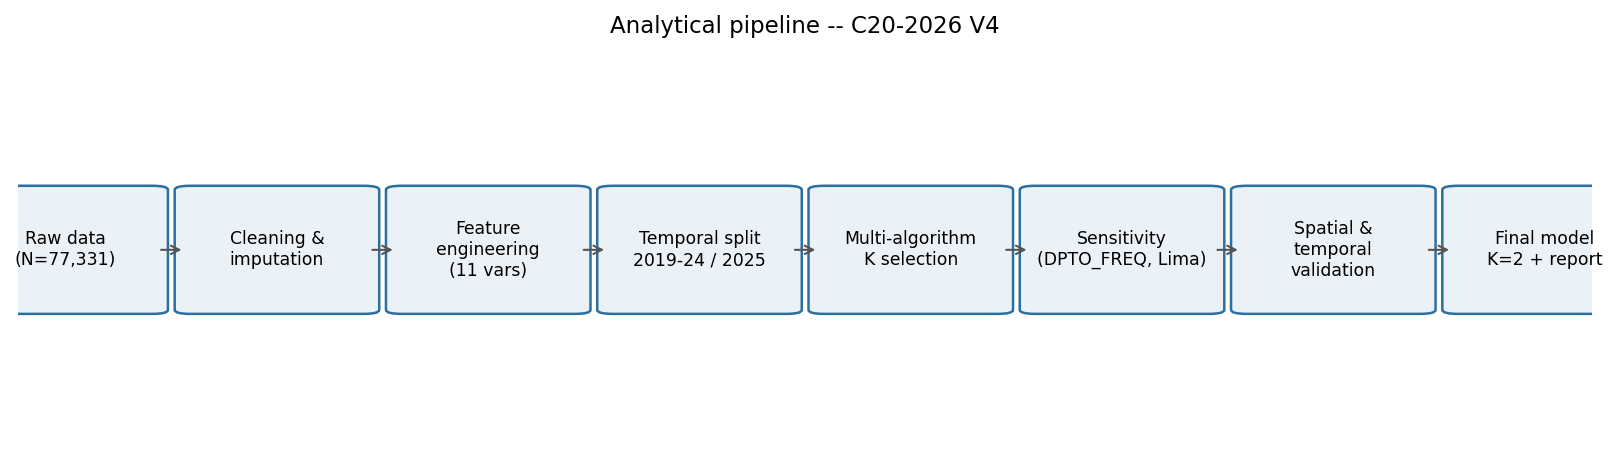

In [10]:
from IPython.display import Image, display
display(Image(filename='fig1_pipeline.png'))

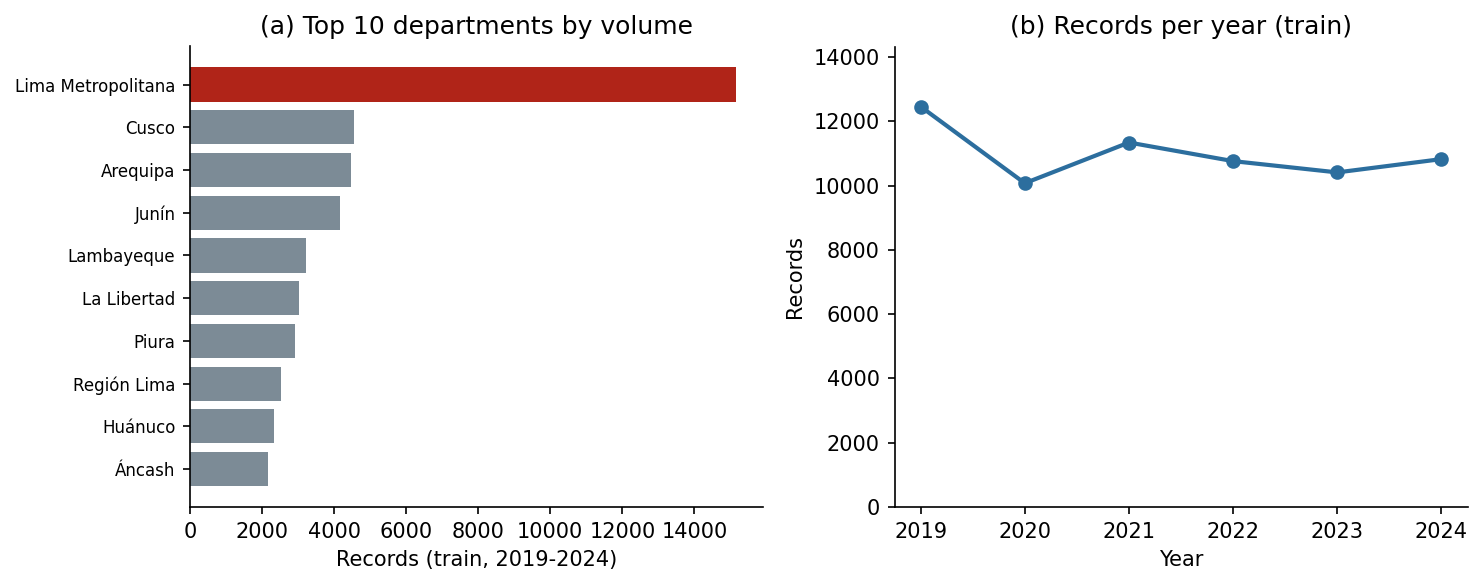

In [11]:
from IPython.display import Image, display
display(Image(filename='fig2_data_overview.png'))

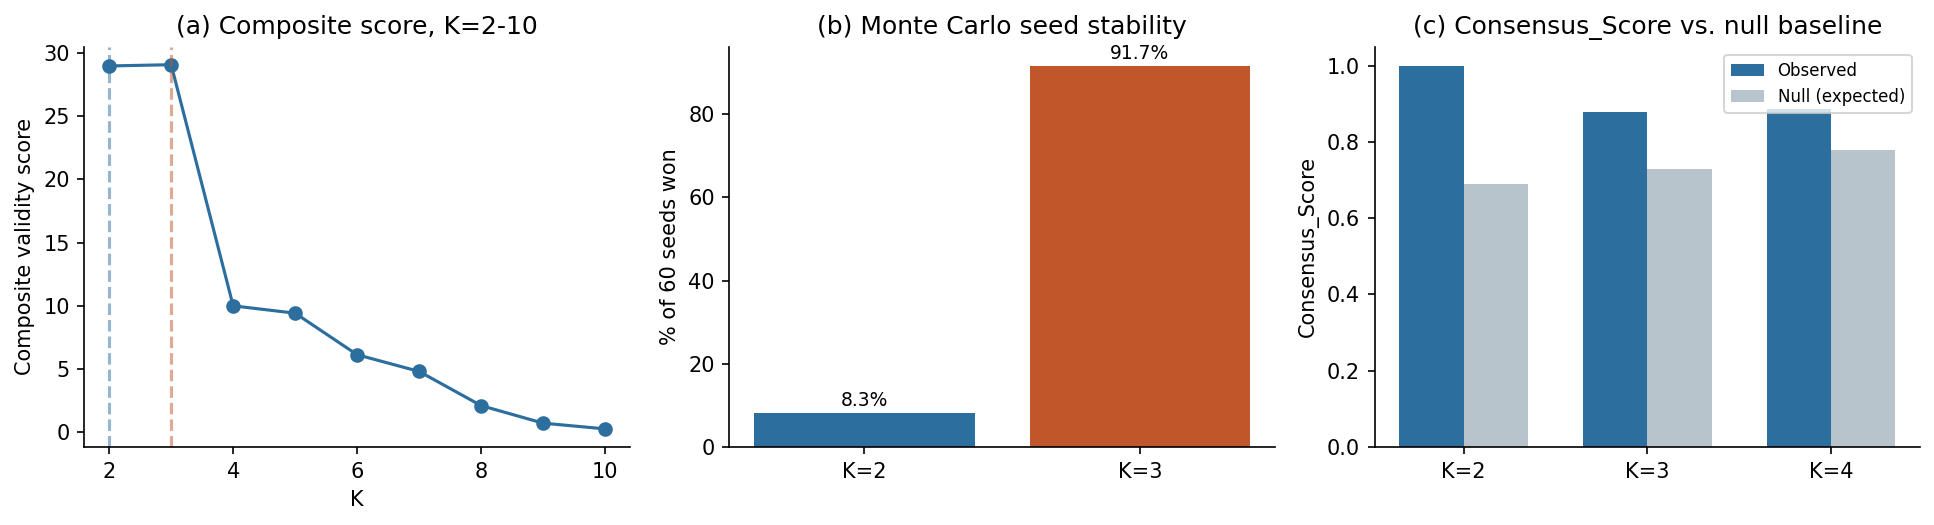

In [12]:
from IPython.display import Image, display
display(Image(filename='fig3_k_selection.png'))

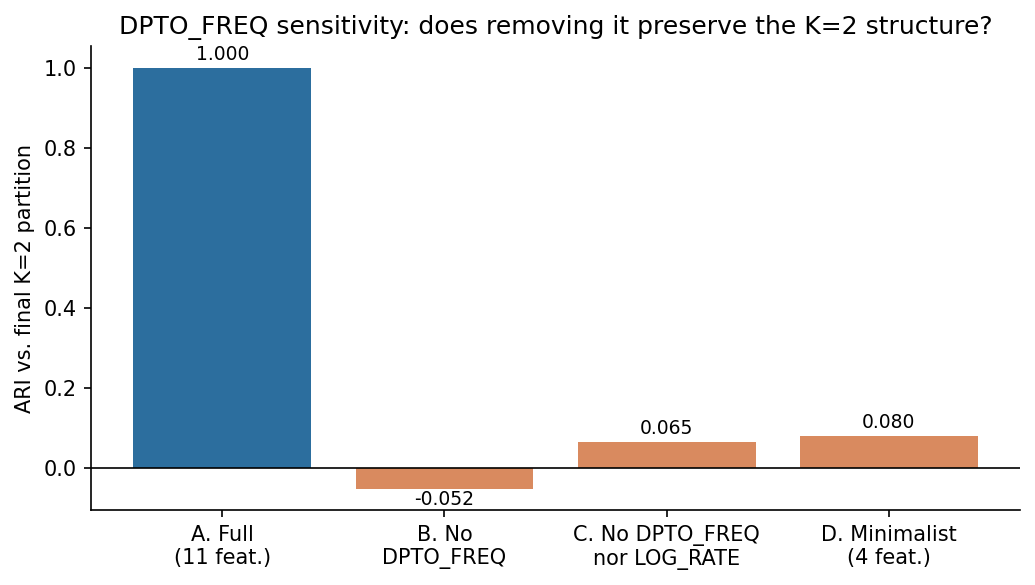

In [13]:
from IPython.display import Image, display
display(Image(filename='fig4_dptofreq_sensitivity.png'))

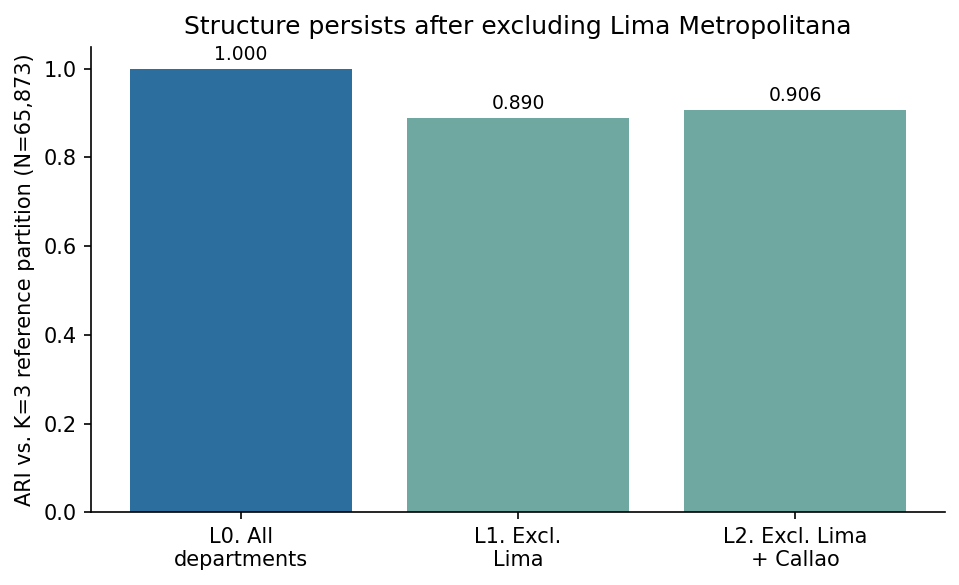

In [14]:
from IPython.display import Image, display
display(Image(filename='fig5_lima_sensitivity.png'))

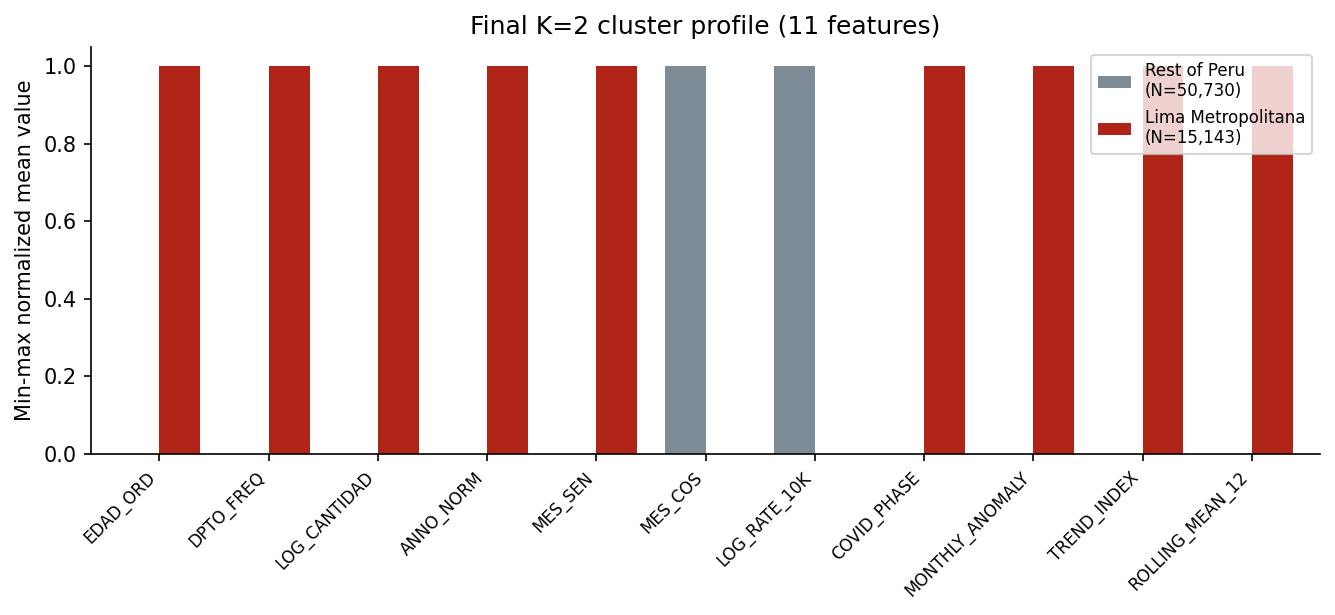

In [15]:
from IPython.display import Image, display
display(Image(filename='fig6_cluster_profile.png'))

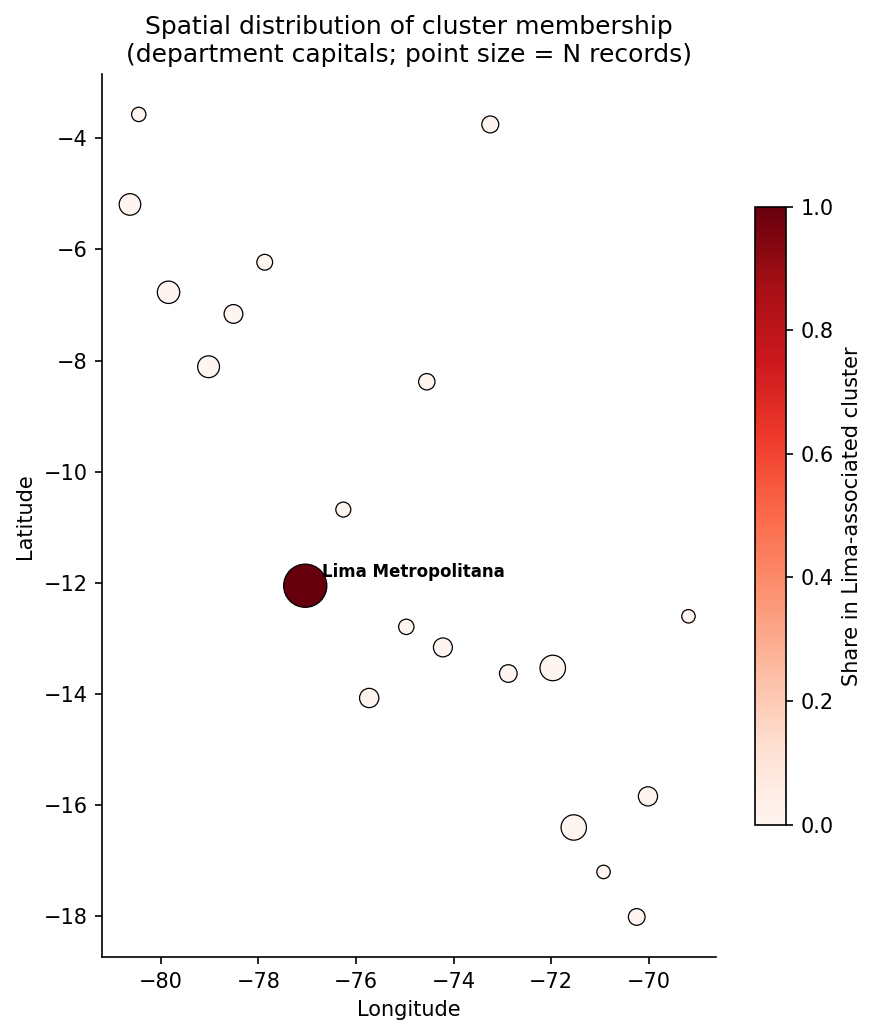

In [16]:
from IPython.display import Image, display
display(Image(filename='fig7_spatial.png'))

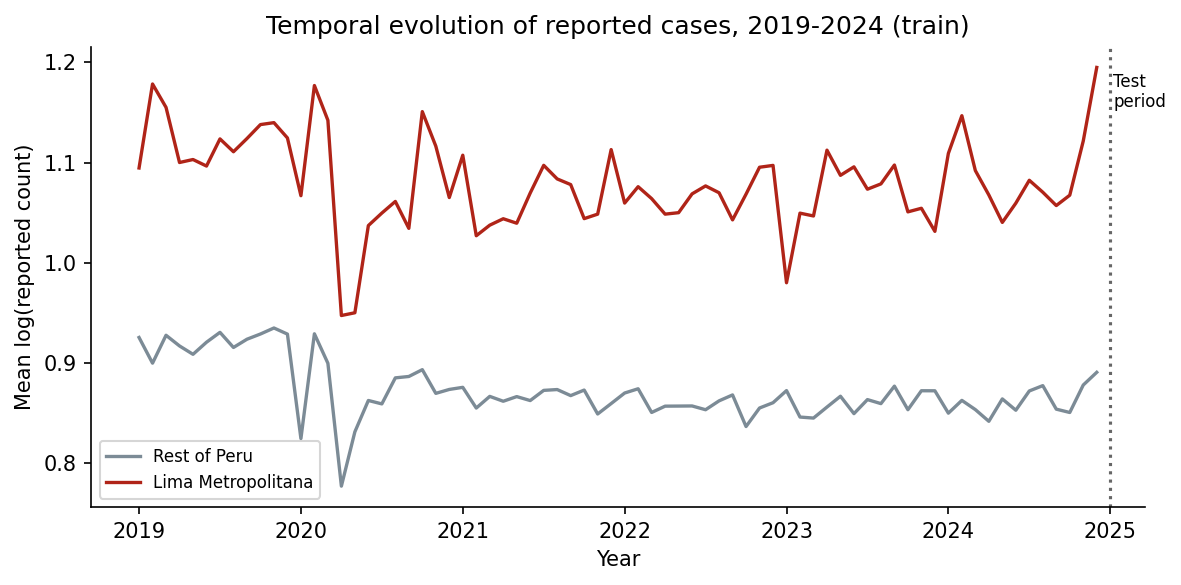

In [17]:
from IPython.display import Image, display
display(Image(filename='fig8_temporal.png'))

## Section 21 -- Final validation summary
All headline numbers reported in the accompanying manuscript (`CEUS_Manuscript_Final.docx`)
and in `FINAL_AUDIT_REPORT.md` are read from `results_k.json`, which this notebook populates
top-to-bottom. Re-running it end-to-end regenerates that file (subject only to Monte-Carlo/
permutation-test seed variation documented inline in each section), which is the
reproducibility contract for this submission.

## Section 23 -- Final conclusions

- **Final model: K=2** (Lima Metropolitana vs. the rest of Peru), selected on a multi-criteria
  balance of validity, algorithm-family stability, Consensus_Score net of a null baseline,
  spatial/temporal coherence and interpretability (decision table in the section above).
- The K=2 structure is **highly dependent on `DPTO_FREQ`**: removing it drops the ARI against
  the full-feature partition to approximately zero -- reported explicitly, not minimized.
- **K=3 is retained as a documented, reproducible secondary finding** (Monte-Carlo-preferred
  in 91.7% of seeds under the original design), whose extra cluster is best described as a
  temporal-volatility regime (driven by `MONTHLY_ANOMALY`/`LOG_RATE_10K`), not a third
  territorial category: it is the majority label in only 2 of 26 departments.
- Socioeconomic "external validation" is **only valid when computed at the department level**
  (N=25/24); the individual-level version is pseudoreplicated and inflates significance.
- The previously reported Getis-Ord G anomaly is a **mathematical degeneracy** (0/0 division
  for a near-constant indicator variable: 20 of 21 departments have `CLUSTER1_SHARE=0`), not
  evidence of spatial autocorrelation; it has been removed from the inferential argument.
- The model **generalizes to the fully held-out 2025 test year** without refitting
  (ARI=1.0000, 100% precision/recall for the Lima-associated cluster).